---

# Task 1: Familiarize Yourself with the Dataset

There are two main subtasks:  
1. Load the four data files that are part of this dataset.  
2. Explore each dataset and define the data types of each column. Describe the contents of each column, including the nature of the data values. Follow a similar approach as demonstrated in the lecture and tutorial. Discuss the shape of the data, value ranges, and possible categories. Convert any data into a more appropriate format if needed.  

Add as many code and markdown cells as necessary below. Typically, you should perform one type of investigation per code cell with output, and then comment on the results in a markdown cell below it.  

After completing the analysis, write a concise summary in the **Task 1: summary report** cell at the end. The final report should succinctly summarize the main characteristics of each data file, how they relate to each other, and any notable features.


## Loading the Data

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sessions_df = pd.read_csv('data/sessions.csv')
streamers_df = pd.read_csv('data/streamers.csv')
streams_df = pd.read_csv('data/streams.csv')
viewers_df = pd.read_csv('data/viewers.csv')

## Exploring the Data - sessions.csv

### Columns

In [4]:
sessions_df.head()

,session_id,viewer_id,streamer_id,stream_id,started_at,ended_at,duration_mins,chat_messages_sent,bits_cheered,followed_during,subscribed_during
0,SES000001,VWR00938,STR0055,SM00860,2024-01-18 19:16:00,2024-01-18 20:28:00,72,0,0,False,False
1,SES000002,VWR00804,STR0034,SM00542,2024-01-04 17:11:00,2024-01-04 19:41:00,150,11,0,False,False
2,SES000003,VWR00704,STR0008,SM00124,2024-02-15 15:11:00,2024-02-15 16:53:00,102,5,0,False,False
3,SES000004,VWR00926,STR0024,SM00373,2024-01-18 19:59:00,2024-01-18 20:56:00,57,3,9663,False,False
4,SES000005,VWR00883,STR0008,SM00120,2024-03-19 20:08:00,2024-03-19 20:22:00,14,7,0,False,False


- session_id appears to be a unique identifier for a session consisting of: a unique viewer, stream, streamer combination
- viewer_id appears to be an identifier for the viewer in the session
- streamer_id appears to be an identifier for the streamer the viewer's watching in the session
- stream_id appears to be an identifier for the stream that a viewer is watching in the session
- started_at appears to be a datetime for when the viewer began watching the stream (we can tell because in the dataset, different sessions for the same stream have different datetimes)
- ended_at appears to be a datetime for when the viewer finished watching the stream (same reasoning as started_at)
- duration_mins appears to be a count of the minutes the viewer watched the stream for
- chat_messages_sent appears to be a count of the chat messages sent by the viewer
- bits_cheered appears to be a count of the bits cheered by the viewer 
- followed_during appears to be a boolean checking whether the viewer followed the streamer during the session
- subscribed_during appears to be a boolean checking whether the viewer subscribed to the streamer during the session

### Data Types 

In [5]:
sessions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22825 entries, 0 to 22824
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   session_id          22825 non-null  object
 1   viewer_id           22825 non-null  object
 2   streamer_id         22765 non-null  object
 3   stream_id           22825 non-null  object
 4   started_at          22825 non-null  object
 5   ended_at            22825 non-null  object
 6   duration_mins       22825 non-null  int64 
 7   chat_messages_sent  22825 non-null  int64 
 8   bits_cheered        22825 non-null  int64 
 9   followed_during     22825 non-null  bool  
 10  subscribed_during   22825 non-null  bool  
dtypes: bool(2), int64(3), object(6)
memory usage: 1.6+ MB


- int64 is used for duration_mins. chat_messages_sent, and bits_cheered. This is fine, as they're counts. 
- bool is used for followed_during and subscribed_during. This is also fine, as they're simple checks. 
- We can see that many of the columns are using the dtype 'object'. In pandas, this is a catch-all dtype. It's usually used for strings, as it is for session_id, viewer_id, and streamer_id. It is fine for these, as they're string identifiers. 
  - However, 'object' dtype is also being used for started_at and ended_at columns. These are datetimes. They should be using datetime dtype, otherwise we will be unable to do date math on them. 

Let's convert started_at and ended_at to use datetime. 

In [6]:
sessions_df['started_at'] = pd.to_datetime(sessions_df['started_at'])
sessions_df['ended_at']   = pd.to_datetime(sessions_df['ended_at'])

In [7]:
sessions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22825 entries, 0 to 22824
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   session_id          22825 non-null  object        
 1   viewer_id           22825 non-null  object        
 2   streamer_id         22765 non-null  object        
 3   stream_id           22825 non-null  object        
 4   started_at          22825 non-null  datetime64[ns]
 5   ended_at            22825 non-null  datetime64[ns]
 6   duration_mins       22825 non-null  int64         
 7   chat_messages_sent  22825 non-null  int64         
 8   bits_cheered        22825 non-null  int64         
 9   followed_during     22825 non-null  bool          
 10  subscribed_during   22825 non-null  bool          
dtypes: bool(2), datetime64[ns](2), int64(3), object(4)
memory usage: 1.6+ MB


Perfect!

### Shape, Ranges, and Categories

In [8]:
sessions_df.shape

(22825, 11)

In [9]:
sessions_df.describe()

,started_at,ended_at,duration_mins,chat_messages_sent,bits_cheered
count,22825,22825,22825.000000,22825.000000,22825.000000
mean,2024-02-14 07:00:46.236144896,2024-02-14 07:59:41.457174016,59.051303,6.442629,398.425323
min,2024-01-01 08:20:00,2024-01-01 08:24:00,0.000000,0.000000,0.000000
25%,2024-01-23 13:18:00,2024-01-23 14:20:00,15.000000,0.000000,0.000000
50%,2024-02-13 14:48:00,2024-02-13 15:57:00,39.000000,1.000000,0.000000
75%,2024-03-07 20:09:00,2024-03-07 21:23:00,83.000000,5.000000,0.000000
max,2024-03-31 01:22:00,2024-03-31 01:54:00,443.000000,1987.000000,10000.000000
std,NaN,NaN,60.383979,46.576309,1571.528658


A category is a column whose values come from a limited, fixed set of options rather than being free-form numbers or text. 

I believe followed_during and subscribed_during are categories for this dataset. 

In [10]:
sessions_df['followed_during'].value_counts()

followed_during
False    21663
True      1162
Name: count, dtype: int64

In [11]:
sessions_df['subscribed_during'].value_counts()

subscribed_during
False    22383
True       442
Name: count, dtype: int64

The output from these makes sense. There are only True or False for both of them. Both are skewed towards false, since following and subscribing are relatively rare events. 

## Exploring the Data - streamers.csv

### Columns

In [12]:
streamers_df.head()

,streamer_id,streamer_name,category,language,partner_status,total_followers,avg_concurrent_viewers
0,STR0001,xQc,Just Chatting,English,True,11500000,138706
1,STR0002,Pokimane,Just Chatting,English,True,-25551,71660
2,STR0003,HasanAbi,Just Chatting,English,True,2600000,34220
3,STR0004,Amouranth,Just Chatting,English,True,6200000,68607
4,STR0005,Mizkif,Just Chatting,English,True,2100000,6771


- streamer_id appears to be a unique identifier for a unique streamer
- streamer_name appears to be the name of the streamer
- category appears to be the activity the streamer's currently doing (or usually does? Not clear)
- language appears to be the language the streamer speaks/communicates in
- partner_status appears to be a boolean checking whether the streamer is a Twitch partner or not
- total_followers appears to be a count of the streamer's followers (at the time the data was collected)
- avg_concurrent_viewers appears to be a count of the average number of viewers in the streamer's stream at once 

NOTE that the second row of the dataset shows a negative amount of followers for Pokimane. This is likely an error that will need to be cleaned. 

### Data Types

In [13]:
streamers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   streamer_id             76 non-null     object
 1   streamer_name           76 non-null     object
 2   category                76 non-null     object
 3   language                68 non-null     object
 4   partner_status          76 non-null     bool  
 5   total_followers         76 non-null     int64 
 6   avg_concurrent_viewers  76 non-null     int64 
dtypes: bool(1), int64(2), object(4)
memory usage: 3.8+ KB


- As mentioned, object dtype is used commonly for strings. Here, it's used for streamer_id, streamer_name, category, and language. These are all fine as these are identifiers and categories, so they must be text. 
- bool is used for partner_status. This is good as it's a category with only two options. 
- int64 is used for total_followers and and avg_concurrent_viewers. This is good for both of them because we are counting people, so we'd like whole numbers. 

### Shape, Ranges, and Categories

In [14]:
streamers_df.shape

(76, 7)

In [15]:
streamers_df.describe()

,total_followers,avg_concurrent_viewers
count,7.600000e+01,76.000000
mean,3.300886e+06,31227.986842
std,3.793772e+06,38307.223652
min,-4.696400e+04,634.000000
25%,7.800000e+05,6633.250000
50%,2.000000e+06,14762.500000
75%,3.875000e+06,36840.750000
max,1.870000e+07,156401.000000


Note negative total_followers as the min value. Must be cleaned. 

For this dataset, the categories are category (duh!), language, and partner_status.

In [16]:
streamers_df['category'].value_counts()

category
Just Chatting    18
FPS              13
Creative         13
MOBA             12
Sports           11
IRL               9
Name: count, dtype: int64

In [17]:
streamers_df['language'].value_counts()

language
English       61
Spanish        5
Korean         1
Portuguese     1
Name: count, dtype: int64

In [18]:
streamers_df['partner_status'].value_counts()

partner_status
True     66
False    10
Name: count, dtype: int64

Looks Good!

## Exploring the Data - streams.csv

### Columns

In [19]:
streams_df.head()

,stream_id,streamer_id,started_at,ended_at,stream_duration_hrs,category,peak_viewers,title_has_hype_word,was_raid
0,SM00001,STR0001,2024-02-14 18:00:00,2024-02-14 21:00:00,3.0,Just Chatting,108989.0,False,True
1,SM00002,STR0001,2024-01-28 18:00:00,2024-01-28 21:00:00,3.0,Just Chatting,51635.0,True,False
2,SM00003,STR0001,2024-01-31 09:00:00,2024-01-31 16:00:00,7.0,Just Chatting,212127.0,False,False
3,SM00004,STR0001,2024-03-03 14:00:00,2024-03-03 21:00:00,7.0,Just Chatting,186745.0,False,True
4,SM00005,STR0001,2024-01-24 18:00:00,2024-01-24 21:00:00,3.0,Just Chatting,87723.0,False,True


- stream_id appears to be a unique identifier for a unique stream
- streamer_id appears to be the name of the streamer who is streaming
- started_at appears to be the datetime that the stream began
- ended_at appears to be the datetime that the stream ended at 
- stream_duration_hrs appears to be the length of the stream in hours (float)
- category appears to be the activity that the streamer was doing during the stream
- peak_viewers appears to be a count of the most viewers that the stream had, at once 
- title_has_hype_word appears to be a bool that checks whether the title of the stream contained a "hype word" (unclear what this is)
- was_raid appears to be a bool that checks whether the stream was "raided" by the viewers of another streamer

NOTE we had to convert datetimes from object dtype to datetime for other dataset, may have to do the same for this one

### Data Types

In [20]:
streams_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1199 entries, 0 to 1198
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   stream_id            1199 non-null   object 
 1   streamer_id          1199 non-null   object 
 2   started_at           1199 non-null   object 
 3   ended_at             1199 non-null   object 
 4   stream_duration_hrs  1199 non-null   float64
 5   category             1149 non-null   object 
 6   peak_viewers         1119 non-null   float64
 7   title_has_hype_word  1199 non-null   bool   
 8   was_raid             1199 non-null   bool   
dtypes: bool(2), float64(2), object(5)
memory usage: 68.0+ KB


- object dtype is used for stream_id, streamer_id, started_at, ended_at, and category. Most are fine as these are identifiers and categories, so they must be text. 
  - However, as before, we must convert started_at and ended_at to datetime dtype in order to be able to do math with them later
- bool is used for title_has_hype_word and was_raid. This is good as they're categories with only two options. 
- float64 is used for stream_duration_hrs and and peak_viewers. This is good for stream_duration_hrs because the duration of the stream may not be in a whole number. 
  - peak_viewers probably shouldn't be a float, since we're counting people. This potentially points to a data issue. We'll investigate later, but leave it for now. 

In [21]:
# convert started_at and ended_at to datetime
streams_df['started_at'] = pd.to_datetime(streams_df['started_at'])
streams_df['ended_at']   = pd.to_datetime(streams_df['ended_at'])

In [22]:
streams_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1199 entries, 0 to 1198
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   stream_id            1199 non-null   object        
 1   streamer_id          1199 non-null   object        
 2   started_at           1199 non-null   datetime64[ns]
 3   ended_at             1199 non-null   datetime64[ns]
 4   stream_duration_hrs  1199 non-null   float64       
 5   category             1149 non-null   object        
 6   peak_viewers         1119 non-null   float64       
 7   title_has_hype_word  1199 non-null   bool          
 8   was_raid             1199 non-null   bool          
dtypes: bool(2), datetime64[ns](2), float64(2), object(3)
memory usage: 68.0+ KB


Perfect!

### Shape, Ranges, and Categories

In [23]:
streams_df.shape

(1199, 9)

In [24]:
streams_df.describe()

,started_at,ended_at,stream_duration_hrs,peak_viewers
count,1199,1199,1199.000000,1119.000000
mean,2024-02-14 08:18:33.928273408,2024-02-14 12:05:27.272727296,4.625104,38375.658624
min,2024-01-01 08:00:00,2024-01-01 10:30:00,1.500000,-50.000000
25%,2024-01-23 18:30:00,2024-01-23 22:30:00,2.500000,7598.500000
50%,2024-02-13 17:00:00,2024-02-13 21:00:00,3.000000,20224.000000
75%,2024-03-07 15:30:00,2024-03-07 20:00:00,5.000000,47941.000000
max,2024-03-30 21:00:00,2024-03-31 02:00:00,96.000000,370165.000000
std,NaN,NaN,7.995028,50377.085406


Note negative min peak_viewers. Must be cleaned. 

For this dataset, the categories are category (duh!), title_has_hype_word, and was_raid

In [25]:
streams_df['category'].value_counts()

category
Just Chatting    275
FPS              208
Creative         191
Sports           178
MOBA             170
IRL              127
Name: count, dtype: int64

In [26]:
streams_df['title_has_hype_word'].value_counts()

title_has_hype_word
False    853
True     346
Name: count, dtype: int64

In [27]:
streams_df['was_raid'].value_counts() 

was_raid
False    1032
True      167
Name: count, dtype: int64

Looks Right!

## Exploring the Data - viewers.csv

### Columns

In [28]:
viewers_df.head()

,viewer_id,age_group,country,account_age_days,subscription_tier,preferred_category
0,VWR00001,18-24,AR,355,free,IRL
1,VWR00002,25-34,CA,1670,free,Creative
2,VWR00003,35-44,US,1108,free,Just Chatting
3,VWR00004,45+,NaN,822,tier1,FPS
4,VWR00005,25-34,DE,2226,free,Just Chatting


- viewer_id appears to be a unique identifier for a unique viewer
- age-group appears to be a the age category that the viewer belongs to 
- country appears to be the country the viewer belongs to 
- account_age_days appears to be the age of the viewer's account, in days
- subscription tier appears to be the subscription tier of the viewer's account 
- preferred_category appears to be the category that the viewer likes to watch most often

### Data Types

In [29]:
viewers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   viewer_id           1000 non-null   object
 1   age_group           1000 non-null   object
 2   country             920 non-null    object
 3   account_age_days    1000 non-null   int64 
 4   subscription_tier   1000 non-null   object
 5   preferred_category  1000 non-null   object
dtypes: int64(1), object(5)
memory usage: 47.0+ KB


- object dtype is used for viewer_id, age_group, country, subscription_tier, and preferred_category. These are fine as these are identifiers and categories, so they must be text. 
- int64 is used for account_age_days. This is good because we are counting days, so we'd like whole numbers. 

### Shape, Ranges, and Categories

In [30]:
viewers_df.shape

(1000, 6)

In [31]:
viewers_df.describe()

,account_age_days
count,1000.000000
mean,1881.119000
std,1036.144656
min,33.000000
25%,984.500000
50%,1966.500000
75%,2761.250000
max,3645.000000


For this dataset, the categories are age_group, country, subscription_tier, and preferred_category.

In [32]:
viewers_df['age_group'].value_counts()

age_group
18-24       334
25-34       289
35-44       134
45+         111
13-17        95
18–24        11
18 to 24     11
25–34         6
35 to 44      4
25 to 34      3
35–44         2
Name: count, dtype: int64

This is concerning. There are multiple categories for what should be the same. We'll address this in cleaning. 

In [33]:
viewers_df['country'].value_counts()

country
US       264
GB        82
CA        66
DE        53
BR        51
FR        47
KR        44
MX        40
other     38
JP        33
AU        31
IT        28
NL        22
ES        21
RU        20
AR        19
SE        19
IN        18
PL        17
TR         7
Name: count, dtype: int64

Looks ok. 

In [34]:
viewers_df['subscription_tier'].value_counts()

subscription_tier
free          578
tier1         243
tier2         100
tier3          49
premium        10
none            7
TIER1           5
free trial      4
tier4           4
Name: count, dtype: int64

Again, concerning. Multiple tier 1s. Will need to address in cleaning. 

In [35]:
viewers_df['preferred_category'].value_counts() 

preferred_category
Just Chatting    269
FPS              230
MOBA             161
IRL              120
Creative         117
Sports           103
Name: count, dtype: int64

Looks fine. 

## Task 1 Summary Report

The sessions.csv file is the main file of the dataset, containing the data for each viewing session, including the streamer, the viewer, the stream itself, and other details of the session. The streamers.csv file holds the data for each streamer, such as their ID, username, and the language they speak. Similarly, the viewers.csv file holds the data for each viewer, including their ID, age group, and country, while the streams.csv file holds the data for each stream, such as its start and end time, its length, and its category. The four files are linked by shared identifiers: sessions.csv connects to the other three tables through viewer_id, streamer_id, and stream_id, which join to streamers.csv, viewers.csv, and streams.csv respectively. Some of the issues found across these files include the datetime columns being stored as text (object dtype) in both sessions.csv and streams.csv, inconsistent category labels in viewers.csv (multiple variants of what should be single age_group and subscription_tier categories), and an impossible negative follower count in streamers.csv and others.

# Task 2: Data Cleaning, Diagnostics, and Corrections

Identify and resolve issues in the dataset. These can be of different kinds, such as:
- Look for duplicates or implausible values (e.g., users with negative followers, invalid age groups). Thoroughly document your exploration of the data. Decide whether these are outliers or the result of a systemic problem. If the latter, resolve the problem here; if they are outliers, we will address those later.  
- Define at least three heuristics (common-sense rules) to flag unusual entries (e.g., someone watching dozens of streams per day). Discuss whether what you found are errors or artifacts.  

I will repeat the instructions here, but this is expected for each task: each code cell should focus on a specific analysis. You should run the code, and in the markdown below each code cell and its result, provide a detailed interpretation of what you have uncovered in that step. After completing the analyses, summarize the key findings in the indicated summary report cell below.


## Heuristics 

Some heuristics:
1. A viewer cannot watch a stream for longer than the stream lasted. 

2. A viewer's session start/end times must be between a stream's start/end times. 
3. The duration of a viewer's session must match the end time - the start time and cannot be negative.
4. The duration of a stream must match the end time and cannot be negative.
5. A stream cannot have negative peak viewers.  
6. Viewers cannot watch more than 24 hours of streams in a day.
7. Viewers cannot send more chat messages in a session than the (number of seconds they were in it for) * (3.4) (Twitch frequency limits)
8. Viewers' accounts cannot be older than Twitch (launched in June 2011) or negative.
9. Viewers cannot cheer more than 500,000 bits in a day (Twitch purchase limit) or cheer negative bits.
10. Streamers cannot have negative followers or avg_concurrent_viewers. 
11. IDs must match a given format.

Lets check each of these and clean systematic errors. 

## Cleaning sessions.csv

### ID Errors and Bool Checks

Check that all of the ID columns contain only object dtypes. 

In [36]:
# Check that all of the ID columns contain only object dtypes. 
id_columns = ['session_id', 'streamer_id', 'stream_id', 'viewer_id']
for col in id_columns:
    if col in sessions_df.columns:
        if not pd.api.types.is_object_dtype(sessions_df[col]):
            print(f"Warning: {col} in sessions_df is not an object dtype")
    if col in streamers_df.columns:
        if not pd.api.types.is_object_dtype(streamers_df[col]):
            print(f"Warning: {col} in streamers_df is not an object dtype")
    if col in streams_df.columns:
        if not pd.api.types.is_object_dtype(streams_df[col]):
            print(f"Warning: {col} in streams_df is not an object dtype")
    if col in viewers_df.columns:
        if not pd.api.types.is_object_dtype(viewers_df[col]):
            print(f"Warning: {col} in viewers_df is not an object dtype") 

Let's check for missing values in each of the ID columns. 

In [37]:
# check for missing values in each of the ID columns of sessions_df. 
for col in ['session_id', 'viewer_id', 'streamer_id', 'stream_id']:
    missing_values = sessions_df[col].isnull().sum()
    print(f"{col}: {missing_values} missing values")

session_id: 0 missing values
viewer_id: 0 missing values
streamer_id: 60 missing values
stream_id: 0 missing values


There are some missing values for streamer_id. We'll deal with this in task 4. 

- Session ID has to start with SES, followed by 6 numbers. 

- Viewer ID has to start with VWR, followed by 5 numbers. 
- Streamer ID has to start with STR, followed by 4 numbers. 
- Stream ID has to start with SM, followed by 5 numbers. 

Let's check all of these. 

In [38]:
# check for invalid session ids
invalid_session_ids = sessions_df[~sessions_df['session_id'].str.match(r'^SES\d{6}$', na=False)]
print(f"{len(invalid_session_ids)} rows have invalid session_id values")

# check for invalid viewer ids
invalid_viewer_ids = sessions_df[~sessions_df['viewer_id'].str.match(r'^VWR\d{5}$', na=False)]
print(f"{len(invalid_viewer_ids)} rows have invalid viewer_id values")

# check for invalid streamer ids
invalid_streamer_ids = sessions_df[~sessions_df['streamer_id'].str.match(r'^STR\d{4}$', na=False)]
print(f"{len(invalid_streamer_ids)} rows have invalid streamer_id values")

# check for invalid stream ids
invalid_stream_ids = sessions_df[~sessions_df['stream_id'].str.match(r'^SM\d{5}$', na=False)]
print(f"{len(invalid_stream_ids)} rows have invalid stream_id values")

0 rows have invalid session_id values
0 rows have invalid viewer_id values
60 rows have invalid streamer_id values
0 rows have invalid stream_id values


These are fine. The 60 invalid ones for streamer ID are coming from the missing values. 

Let's also check to make sure that followed_during and subscribed_during contain only bools

In [39]:
# check to make sure that followed_during and subscribed_during contain only bools
invalid_followed_during = sessions_df[~sessions_df['followed_during'].isin([True, False])]
print(f"{len(invalid_followed_during)} rows have invalid followed_during values")

invalid_subscribed_during = sessions_df[~sessions_df['subscribed_during'].isin([True, False])]
print(f"{len(invalid_subscribed_during)} rows have invalid subscribed_during values")

0 rows have invalid followed_during values
0 rows have invalid subscribed_during values


And check for missing values in followed_during and subscribed_during.

In [40]:
# check for missing values in followed_during and subscribed_during.
missing_followed_during = sessions_df['followed_during'].isnull().sum()
missing_subscribed_during = sessions_df['subscribed_during'].isnull().sum()
print(f"followed_during: {missing_followed_during} missing values")
print(f"subscribed_during: {missing_subscribed_during} missing values")

followed_during: 0 missing values
subscribed_during: 0 missing values


Perfect.

### Date Time Errors

In [41]:
# how many rows in sessions.csv have a duration that does not match end time - start time
computed_duration = (sessions_df['ended_at'] - sessions_df['started_at']).dt.total_seconds() / 60
mismatched = (computed_duration != sessions_df['duration_mins']).sum()
print(f"{mismatched} rows have a duration_mins that does not match ended_at - started_at")

70 rows have a duration_mins that does not match ended_at - started_at


Ok, 70 problem rows. Lets check for negatives, missing values, and non date time dtypes. 

In [42]:
# check for non date time dtype in started_at and ended_at columns in sessions_df
non_datetime_started_at = sessions_df['started_at'].apply(lambda x: not isinstance(x, pd.Timestamp)).sum()
non_datetime_ended_at = sessions_df['ended_at'].apply(lambda x: not isinstance(x, pd.Timestamp)).sum()
print(f"{non_datetime_started_at} rows have a non-datetime value in started_at")

0 rows have a non-datetime value in started_at


In [43]:
# how many of these are negative?
negative_durations = (sessions_df['duration_mins'] < 0).sum()
print(f"{negative_durations} rows have a negative duration_mins")

0 rows have a negative duration_mins


In [44]:
# how many missing values for duration_mins?
missing_durations = sessions_df['duration_mins'].isna().sum()
print(f"{missing_durations} rows have missing duration values")

0 rows have missing duration values


0 negatives, which is good. Lets take a look at what the problem rows look like. 

In [45]:
# print 10 problem rows
problem_rows = sessions_df[computed_duration != sessions_df['duration_mins']]
print(problem_rows.head(10))

     session_id viewer_id streamer_id stream_id          started_at  \
341   SES000342  VWR00878     STR0010   SM00147 2024-03-19 13:53:00   
722   SES000723  VWR00859     STR0020   SM00311 2024-03-15 14:53:00   
1011  SES001012  VWR00722     STR0076   SM01199 2024-02-19 08:36:00   
1259  SES001260  VWR00620     STR0011   SM00163 2024-03-02 10:20:00   
1457  SES001458  VWR00613     STR0075   SM01186 2024-01-04 18:38:00   
1718  SES001719  VWR00916     STR0073   SM01160 2024-02-13 19:38:00   
1897  SES001898  VWR00947     STR0020   SM00303 2024-01-01 11:18:00   
2662  SES002663  VWR00369     STR0041   SM00659 2024-03-23 16:08:00   
2679  SES002680  VWR00622     STR0026   SM00408 2024-03-13 12:23:00   
2708  SES002709  VWR00444     STR0032   SM00510 2024-02-17 22:51:00   

                ended_at  duration_mins  chat_messages_sent  bits_cheered  \
341  2024-03-19 12:15:00             98                   3             0   
722  2024-03-15 11:57:00            176                  25     

There appears to be a systematic error here. For most of the problem rows in the above sample, the start time is *after* the end time. If you treat the end time as the start time and vice versa, the duration lines up. For example, with row 341, with a start date time of 2024-03-19 13:53 and end date time of 2024-03-19 12:15, there are exactly 98 mins between these times. They are clearly accidentally swapped. 

We will clean the systematic error of all sessions with start time > end time by swapping them. 

However, there is another type of error in the sample we see here. Some rows do have a start time < end time, but the duration just doesn't match the computed duration. Let's clean the first error and then investigate further. 

In [46]:
# clean the first error by swapping start and end times for any row that has start time after end time 
sessions_df.loc[sessions_df['started_at'] > sessions_df['ended_at'], ['started_at', 'ended_at']] = \
    sessions_df.loc[sessions_df['started_at'] > sessions_df['ended_at'], ['ended_at', 'started_at']].values

Ok. Those have been cleaned. Lets look at the remaining problem rows (concerning date times).

In [47]:
# recompute duration and check for mismatches again
computed_duration = (sessions_df['ended_at'] - sessions_df['started_at']).dt.total_seconds() / 60
mismatched = (computed_duration != sessions_df['duration_mins']).sum()
print(f"After cleaning, {mismatched} rows still have a duration_mins that does not match ended_at - started_at")

After cleaning, 30 rows still have a duration_mins that does not match ended_at - started_at


In [48]:
# print the remaining problem rows
problem_rows = sessions_df[computed_duration != sessions_df['duration_mins']]
print(problem_rows.tail(10))

      session_id viewer_id streamer_id stream_id          started_at  \
19357  SES019358  VWR00641     STR0074   SM01181 2024-02-11 16:37:00   
19418  SES019419  VWR00849     STR0034   SM00536 2024-03-26 22:41:00   
19855  SES019856  VWR00851     STR0030   SM00474 2024-03-15 10:09:00   
20697  SES020698  VWR00751     STR0047   SM00737 2024-01-16 00:34:00   
20818  SES020819  VWR00207     STR0056   SM00878 2024-01-13 11:04:00   
20840  SES020841  VWR00850     STR0056   SM00880 2024-03-09 13:22:00   
21611  SES021612  VWR00783     STR0061   SM00959 2024-02-03 18:26:00   
21759  SES021760  VWR00660     STR0010   SM00154 2024-02-10 20:57:00   
21965  SES021966  VWR00951     STR0069   SM01087 2024-01-23 20:12:00   
22613  SES022614  VWR00436     STR0025   SM00390 2024-02-28 11:21:00   

                 ended_at  duration_mins  chat_messages_sent  bits_cheered  \
19357 2024-02-11 17:17:00              5                 848             0   
19418 2024-03-26 22:58:00              2           

Date times seem fine here. The duration is seemingly miscalculated. Looks like a systematic error. However, another thing to flag is the huge amount of chat messages sent by each of these user. This could signal that these are bot accounts that spam messages. We'll come back to this issue. 

We'll clean this by recomputing duration for any rows where the current duration doesn't match computed duration. 

In [49]:
#clean by recomputing duration for any rows where the current duration doesn't match computed duration.
sessions_df.loc[computed_duration != sessions_df['duration_mins'], 'duration_mins'] = computed_duration[computed_duration != sessions_df['duration_mins']]

Let's check once more for rows whose duration does not match end time - start time

In [50]:
# once again compute duration and check for mismatches
computed_duration = (sessions_df['ended_at'] - sessions_df['started_at']).dt.total_seconds() / 60
mismatched = (computed_duration != sessions_df['duration_mins']).sum()  
print(f"After cleaning, {mismatched} rows still have a duration_mins that does not match ended_at - started_at")

After cleaning, 0 rows still have a duration_mins that does not match ended_at - started_at


Awesome! We found issues with number of chat messages sent, so let's deal with that next. 

### Chat Message Errors

Firstly, for missing or negative amount of chat messages sent. Also, non-numbers. 

In [51]:
# check for any non numeric values in chat_messages_sent
non_numeric_chat_messages = sessions_df['chat_messages_sent'].apply(lambda x: not isinstance(x, (int, float))).sum()
print(f"{non_numeric_chat_messages} rows have a non-numeric value in chat_messages_sent") 

0 rows have a non-numeric value in chat_messages_sent


In [52]:
# check for rows with a negative amount of chat messages
negative_chat_messages = (sessions_df['chat_messages_sent'] < 0).sum()
print(f"{negative_chat_messages} rows have a negative amount of chat messages")

0 rows have a negative amount of chat messages


In [53]:
# check for missing values in chat_messages_sent
missing_chat_messages = sessions_df['chat_messages_sent'].isna().sum()  
print(f"{missing_chat_messages} rows have missing chat_messages_sent values")

0 rows have missing chat_messages_sent values


Ok, that's fine. 

Due to Twitch chat frequency limits, the maximum amount of messages a user can send is the number of seconds they were in the session for * 3.4. So, let's check the data matches this. 

In [54]:
# check that the amount of messages a user sent is < the number of seconds they were in the session for * 3.4
max_allowed_messages = sessions_df['duration_mins'] * 60 * 3.4
exceeds_limit = sessions_df['chat_messages_sent'] > max_allowed_messages
print(f"{exceeds_limit.sum()} rows have more chat messages than allowed by Twitch's frequency limit")
sessions_df[exceeds_limit].head(30)

31 rows have more chat messages than allowed by Twitch's frequency limit


,session_id,viewer_id,streamer_id,stream_id,started_at,ended_at,duration_mins,chat_messages_sent,bits_cheered,followed_during,subscribed_during
110,SES000111,VWR00984,STR0009,SM00143,2024-02-07 13:39:00,2024-02-07 13:39:00,0,2,0,False,False
416,SES000417,VWR00347,STR0041,SM00659,2024-03-23 15:40:00,2024-03-23 15:40:00,0,1,0,False,False
826,SES000827,VWR00771,STR0044,SM00692,2024-02-25 18:50:00,2024-02-25 18:50:00,0,1,0,False,False
1325,SES001326,VWR00716,STR0005,SM00079,2024-03-23 21:13:00,2024-03-23 21:13:00,0,9,0,False,False
2046,SES002047,VWR00901,STR0026,SM00420,2024-02-14 16:50:00,2024-02-14 16:50:00,0,3,0,False,False
3009,SES003010,VWR00496,STR0072,SM01137,2024-02-20 20:47:00,2024-02-20 20:47:00,0,1,6578,False,False
3459,SES003460,VWR00666,STR0038,SM00617,2024-01-12 20:11:00,2024-01-12 20:11:00,0,1,0,False,False
4756,SES004757,VWR00976,STR0037,SM00600,2024-02-22 14:18:00,2024-02-22 14:18:00,0,18,0,False,False
7814,SES007815,VWR00781,STR0018,SM00269,2024-02-06 15:30:00,2024-02-06 15:30:00,0,1,0,False,False
8576,SES008577,VWR00962,STR0003,SM00044,2024-01-21 13:06:00,2024-01-21 13:06:00,0,5,0,False,False


Interestingly, the rows we flagged in the cleaning of Date Time errors with high chat amounts do not get flagged here. Those could still be bots, but it is not logically impossible to send the number of chat messages we saw there. 

Interestingly though, all rows that got flagged here have a duration of "0". This points to an error in our heuristic, rather than the data. We did not account for the fact that the date times that are collected rounded to minutes (notice each date time has a second-mark of 00). This means that a session that is less than one minute can be counted as 0 mins. So, a user could come in for less than a minute, send messages, and then leave. This is supported by the idea that the most messages they could send in less than a minute would be 60 * 3.4 = 204. The number of sent chat messages we see are way below this. 

So, I conclude there is no error here, but perhaps the data collection method should be adjusted to look at second-markers as well, so the data is less confusing. 

Let's look at bits cheered next. 

### Cheered Bits Errors

Again, let's first check for missing or negative amounts of cheered bits. Also, non-numbers. 

In [55]:
# check for non numeric values in bits_cheered 
non_numeric_bits_cheered = sessions_df['bits_cheered'].apply(lambda x: not isinstance(x, (int, float))).sum()
print(f"{non_numeric_bits_cheered} rows have a non-numeric value in bits_cheered")

0 rows have a non-numeric value in bits_cheered


In [56]:
# check for negative bits cheered
negative_bits_cheered = (sessions_df['bits_cheered'] < 0).sum()
print(f"{negative_bits_cheered} rows have a negative amount of bits cheered")

0 rows have a negative amount of bits cheered


In [57]:
# check for missing bits cheered values
missing_bits_cheered = sessions_df['bits_cheered'].isna().sum() 
print(f"{missing_bits_cheered} rows have missing bits_cheered values")

0 rows have missing bits_cheered values


No issue. 

Next, let's check that no accounts have cheered more than 500,000 bits in a session, as this is impossible within the span of one day (and extremely unlikely)

In [58]:
# check for any rows that have bits_cheered > 500000
excessive_bits_cheered = (sessions_df['bits_cheered'] > 500000).sum()
print(f"{excessive_bits_cheered} rows have more than 500,000 bits cheered")

0 rows have more than 500,000 bits cheered


There appears to be no errors with amounts of bits cheered. 

## Cleaning streamers.csv

### ID Errors and Bool Checks

First, let's check that streamer IDs are object dtype and for missing values. 

In [59]:
# check that streamer IDs are object dtype
if not pd.api.types.is_object_dtype(streamers_df['streamer_id']):
    print("Warning: streamer_id in streamers_df is not an object dtype")

In [60]:
# check for missing values in streamer_id in streamers_df
missing_streamer_ids = streamers_df['streamer_id'].isnull().sum()
print(f"{missing_streamer_ids} rows have missing streamer_id values in streamers_df")

0 rows have missing streamer_id values in streamers_df


Good there.

Stream ID has to start with SM, followed by 5 numbers.

Let's check these. 

In [61]:
# check for invalid streamer ids
invalid_streamer_ids = streamers_df[~streamers_df['streamer_id'].str.match(r'^STR\d{4}$', na=False)]
print(f"{len(invalid_streamer_ids)} rows have invalid streamer_id values")

0 rows have invalid streamer_id values


Let's check that partner status has only bools and no missing values. 

In [62]:
# check that partner status has only bools
if not pd.api.types.is_bool_dtype(streamers_df['partner_status']):
    print("Warning: partner_status in streamers_df is not a bool dtype")

In [63]:
# check that partner_status has no missing values
missing_partner_status = streamers_df['partner_status'].isnull().sum()
print(f"{missing_partner_status} rows have missing partner_status values in streamers_df")

0 rows have missing partner_status values in streamers_df


Perfect. 

### Total Followers Errors

Let's first check for missing or negative total followers. also, non numbers. 

In [64]:
# check for non numeric values in total_followers
non_numeric_total_followers = streamers_df['total_followers'].apply(lambda x: not isinstance(x, (int, float))).sum()
print(f"{non_numeric_total_followers} rows have a non-numeric value in total_followers")

0 rows have a non-numeric value in total_followers


In [65]:
# check for missing values in total followers
missing_total_followers = streamers_df['total_followers'].isna().sum()
print(f"{missing_total_followers} rows have missing total_followers values")

0 rows have missing total_followers values


In [66]:
# check for negative total followers
negative_total_followers = (streamers_df['total_followers'] < 0).sum()
print(f"{negative_total_followers} rows have a negative total followers count")

5 rows have a negative total followers count


In [67]:
# Let's print the rows with negative total followers to see if there are any other issues with them
streamers_df[streamers_df['total_followers'] < 0]

,streamer_id,streamer_name,category,language,partner_status,total_followers,avg_concurrent_viewers
1,STR0002,Pokimane,Just Chatting,English,True,-25551,71660
6,STR0007,Devin_Nash,Just Chatting,English,True,-45130,5114
7,STR0008,Ibai,Just Chatting,Spanish,True,-46964,156401
12,STR0013,Fuslie,Just Chatting,English,True,-8902,9540
24,STR0025,GeT_RiGhT,FPS,English,True,-36135,10785


There are some streamers with negative follower counts. This is logically impossible and clearly an error. Although there's not *too* many problem rows, there are also not many streamers (only 76). So, 5 is enough to not call these outliers. 

Gut instinct says that this may just be an accidental negative input and we need to simply take the absolute values of total_followers. 
However, this would result in some of these streamers having significantly lower total_followers than their avg concurrent viewers. In addition, it would result in Pokimane having less followers than Devin_Nash. 

So, for now, lets 'clean' by replacing negatives with missing values and handle later. 

In [68]:
# clean by replacing negatives with missing values and handle later. 
streamers_df.loc[streamers_df['total_followers'] < 0, 'total_followers'] = pd.NA

### Avg Concurrent Followers Errors

First, let's check for negative or missing values for this column. And non numbers. 

In [69]:
# check for non numbers in avg_concurrent_viewers
non_numeric_avg_conc = streamers_df['avg_concurrent_viewers'].apply(lambda x: not isinstance(x, (int, float))).sum()
print(f"{non_numeric_avg_conc} rows have a non-numeric value in avg_concurrent_viewers")

0 rows have a non-numeric value in avg_concurrent_viewers


In [70]:
# check for missing values for avg_concurrent_viewers
missing_avg_viewers = streamers_df['avg_concurrent_viewers'].isna().sum()
print(f"{missing_avg_viewers} rows have missing avg_concurrent_viewers values")

0 rows have missing avg_concurrent_viewers values


In [71]:
# check for negative avg_concurrent_viewers
negative_avg_viewers = (streamers_df['avg_concurrent_viewers'] < 0).sum()
print(f"{negative_avg_viewers} rows have a negative avg_concurrent_viewers value")

0 rows have a negative avg_concurrent_viewers value


There appear to be no errors with avg_concurrent_viewers. 

### Category Errors

First, let's check that category has only object dtypes and no missing values. 

In [72]:
# check category for only object dtype values
if not pd.api.types.is_object_dtype(streamers_df['category']):
    print("Warning: category in streamers_df is not an object dtype") 

In [73]:
# check category for missing values
missing_category = streamers_df['category'].isnull().sum()
print(f"{missing_category} rows have missing category values in streamers_df")

0 rows have missing category values in streamers_df


Let's look at category values. 

In [74]:
# print each category and the number of streamers in it 
print(streamers_df['category'].value_counts())

category
Just Chatting    18
FPS              13
Creative         13
MOBA             12
Sports           11
IRL               9
Name: count, dtype: int64


Everything looks good in the category column. 

### Language Errors

First, let's check that language has only object dtypes and for missing values. 

In [75]:
# check language for only object dtype values
if not pd.api.types.is_object_dtype(streamers_df['language']):
    print("Warning: language in streamers_df is not an object dtype")

In [76]:
# check language for missing values
missing_language = streamers_df['language'].isnull().sum()
print(f"{missing_language} rows have missing language values in streamers_df")

8 rows have missing language values in streamers_df


There are 8 missing language values, we will deal with these in task 4. 

Let's take a look at the language categories.

In [77]:
# check language categories and counts
print(streamers_df['language'].value_counts())

language
English       61
Spanish        5
Korean         1
Portuguese     1
Name: count, dtype: int64


Looks good. 

## Cleaning streams.csv 

### ID Errors and Bool Checks

First, let's check that stream IDs and streamer IDs are object dtype and for missing values. 

In [78]:
# check that stream IDs and streamer IDs are object dtype
if not pd.api.types.is_object_dtype(streams_df['stream_id']):
    print("Warning: stream_id in streams_df is not an object dtype")

if not pd.api.types.is_object_dtype(streams_df['streamer_id']):
    print("Warning: streamer_id in streams_df is not an object dtype")

In [79]:
# check for missing values for stream_id and streamer_id in streams_df
missing_stream_ids = streams_df['stream_id'].isnull().sum()
print(f"{missing_stream_ids} rows have missing stream_id values in streams_df")

missing_streamer_ids = streams_df['streamer_id'].isnull().sum()
print(f"{missing_streamer_ids} rows have missing streamer_id values in streams_df")

0 rows have missing stream_id values in streams_df
0 rows have missing streamer_id values in streams_df


Good. 

Again, let's check that the IDs match the format

In [80]:
# check that the IDs match the format
invalid_stream_ids = streams_df[~streams_df['stream_id'].str.match(r'^SM\d{5}$', na=False)]
print(f"{len(invalid_stream_ids)} rows have invalid stream_id values in streams_df")

invalid_streamer_ids = streams_df[~streams_df['streamer_id'].str.match(r'^STR\d{4}$', na=False)]
print(f"{len(invalid_streamer_ids)} rows have invalid streamer_id values in streams_df")

0 rows have invalid stream_id values in streams_df
0 rows have invalid streamer_id values in streams_df


Great. 

Now let's check that title_has_hype_word and was_raid are only bools and have no missing values

In [81]:
# check that title_has_hype_word and was_raid are only bools
if not pd.api.types.is_bool_dtype(streams_df['title_has_hype_word']):
    print("Warning: title_has_hype_word in streams_df is not a bool dtype")

if not pd.api.types.is_bool_dtype(streams_df['was_raid']):
    print("Warning: was_raid in streams_df is not a bool dtype")

In [82]:
# check for missing values in title_has_hype_word and was_raid
missing_title_hype = streams_df['title_has_hype_word'].isnull().sum()
print(f"{missing_title_hype} rows have missing title_has_hype_word values in streams_df")

missing_was_raid = streams_df['was_raid'].isnull().sum()
print(f"{missing_was_raid} rows have missing was_raid values in streams_df")

0 rows have missing title_has_hype_word values in streams_df
0 rows have missing was_raid values in streams_df


### Date Time Errors

Let's check for non date time dtypes and missing values in started_at and ended_at 

In [83]:
# check for non date time dtypes and missing values in started_at and ended_at
if not pd.api.types.is_datetime64_any_dtype(streams_df['started_at']):
    print("Warning: started_at in streams_df is not a datetime dtype")

if not pd.api.types.is_datetime64_any_dtype(streams_df['ended_at']):
    print("Warning: ended_at in streams_df is not a datetime dtype")

In [84]:
# check for missing values in started_at and ended_at
missing_started_at = streams_df['started_at'].isnull().sum()
missing_ended_at = streams_df['ended_at'].isnull().sum()
print(f"{missing_started_at} rows have missing started_at values in streams_df")
print(f"{missing_ended_at} rows have missing ended_at values in streams_df")

0 rows have missing started_at values in streams_df
0 rows have missing ended_at values in streams_df


Let's look to see if all streams have a start time < end time. 

In [85]:
# check for any streams with start time after end time
streams_with_time_issues = (streams_df['started_at'] > streams_df['ended_at']).sum()
print(f"{streams_with_time_issues} rows have a start time after the end time")

0 rows have a start time after the end time


No problem with that. 

Let's check to make sure the duration (in hours) matches a computed duration in hours. 

In [86]:
# check that stream duration (measured in hours) matches end time - start time for streams_df as well
stream_duration_hours = streams_df['stream_duration_hrs']
computed_duration_hours = (streams_df['ended_at'] - streams_df['started_at']).dt.total_seconds() / 3600
duration_mismatch = (stream_duration_hours != computed_duration_hours).sum()
print(f"{duration_mismatch} rows have a stream_duration_hours that does not match ended_at - started_at")

15 rows have a stream_duration_hours that does not match ended_at - started_at


In [87]:
# print the rows with duration mismatches to see if there are any other issues with them
streams_df[stream_duration_hours != computed_duration_hours]

,stream_id,streamer_id,started_at,ended_at,stream_duration_hrs,category,peak_viewers,title_has_hype_word,was_raid
6,SM00007,STR0001,2024-03-05 12:00:00,2024-03-05 16:00:00,48.0,Just Chatting,NaN,True,False
48,SM00049,STR0003,2024-02-02 10:00:00,2024-02-02 15:00:00,72.0,Just Chatting,21516.0,False,False
284,SM00285,STR0018,2024-01-24 14:00:00,2024-01-24 17:00:00,72.0,FPS,69221.0,False,False
332,SM00333,STR0021,2024-02-12 22:00:00,2024-02-13 02:00:00,72.0,FPS,120277.0,False,False
357,SM00358,STR0023,2024-03-16 09:00:00,2024-03-16 12:00:00,48.0,FPS,6073.0,False,True
364,SM00365,STR0024,2024-02-28 22:00:00,2024-02-29 02:00:00,72.0,FPS,37056.0,True,False
372,SM00373,STR0024,2024-01-18 15:00:00,2024-01-18 22:00:00,48.0,FPS,16570.0,True,False
417,SM00418,STR0026,2024-03-15 21:00:00,2024-03-16 02:00:00,72.0,FPS,34674.0,False,False
458,SM00459,STR0029,2024-02-25 21:00:00,2024-02-25 23:30:00,48.0,FPS,42620.0,False,False
546,SM00547,STR0034,2024-02-25 12:00:00,2024-02-25 16:00:00,96.0,MOBA,4750.0,False,True


There are 15 rows with durations that do not match their date times. The durations for these are also all either 48, 72, or 96 hours. There's clearly a systemic error here.

We'll clean by recomputing the correct duration and replacing. 

In [88]:
# replace any duration mismatches by recomputing duration for any rows where the current duration doesn't match computed duration.
streams_df.loc[stream_duration_hours != computed_duration_hours, 'stream_duration_hrs'] = computed_duration_hours[stream_duration_hours != computed_duration_hours]

### Category Errors

Let's check for only object dtypes and missing values in category

In [89]:
# check for only object dtype values in category
if not pd.api.types.is_object_dtype(streams_df['category']):
    print("Warning: category in streams_df is not an object dtype")

# check for missing values in category
missing_category = streams_df['category'].isnull().sum()
print(f"{missing_category} rows have missing category values in streams_df")

50 rows have missing category values in streams_df


There are some missing category values in streams.csv. We will deal with this in task 4. 

### Peak Viewers Errors

Let's check for negative or missing values for peak viewers. And non numbers

In [90]:
# check for non numeric values in peak_viewers
non_numeric_peak_viewers = streams_df['peak_viewers'].apply(lambda x: not isinstance(x, (int, float))).sum()
print(f"{non_numeric_peak_viewers} rows have a non-numeric value in peak_viewers")

0 rows have a non-numeric value in peak_viewers


In [91]:
# check for missing values for peak viewers
missing_peak_viewers = streams_df['peak_viewers'].isnull().sum()
print(f"{missing_peak_viewers} rows have missing peak_viewers values")

80 rows have missing peak_viewers values


In [92]:
# check for negative values for peak viewers
negative_peak_viewers = (streams_df['peak_viewers'] < 0).sum()
print(f"{negative_peak_viewers} rows have a negative peak_viewers value")

40 rows have a negative peak_viewers value


There are missing values for peak viewers. We'll deal with these in task 4. 

There are 40 rows with negative peak viewers. Let's have a look. Let's print the total_followers and avg_concurrent_viewers for each of the streams, so we have some reference. 

In [93]:
# print rows with negative peak viewers to see if there are any other issues with them, also print the total_followers and avg_cocurrent_viewers for the streamer of each stream to have context. 
streams_df_with_streamer_info = streams_df.merge(streamers_df[['streamer_id', 'total_followers', 'avg_concurrent_viewers']], on='streamer_id', how='left')
streams_df_with_streamer_info[streams_df_with_streamer_info['peak_viewers'] < 0][['stream_id', 'streamer_id', 'peak_viewers', 'total_followers', 'avg_concurrent_viewers']].tail(10)


,stream_id,streamer_id,peak_viewers,total_followers,avg_concurrent_viewers
850,SM00851,STR0054,-49.0,1100000.0,11707
855,SM00856,STR0054,-41.0,1100000.0,11707
907,SM00908,STR0058,-11.0,1600000.0,15029
910,SM00911,STR0058,-38.0,1600000.0,15029
978,SM00979,STR0062,-2.0,18700000.0,151923
993,SM00994,STR0063,-18.0,3400000.0,31783
1046,SM01047,STR0067,-16.0,3800000.0,35224
1081,SM01082,STR0068,-10.0,5100000.0,30351
1122,SM01123,STR0071,-1.0,6500000.0,31132
1175,SM01176,STR0074,-8.0,780000.0,3932


When we look at the negative peak viewers alongside the total followers and avg concurrent viewers for these rows, it's clear that an absolute value onto peak viewers wouldn't be accurate. 

Wel'll treat these as missing data for now and move on. 

In [94]:
# replace negative peak viewers with missing values and handle later
streams_df.loc[streams_df['peak_viewers'] < 0, 'peak_viewers'] = pd.NA

## Cleaning viewers.csv

### ID Errors

First, let's check that viewer ID is only object dtype and for missing values. 

In [95]:
# check that viewer ID is only object dtype
if not pd.api.types.is_object_dtype(viewers_df['viewer_id']):
    print("Warning: viewer_id in viewers_df is not an object dtype")

In [96]:
# check for missing values in viewer_id in viewers_df
missing_viewer_ids = viewers_df['viewer_id'].isnull().sum()
print(f"{missing_viewer_ids} rows have missing viewer_id values in viewers_df")

0 rows have missing viewer_id values in viewers_df


Check the format of viewer ID 

In [97]:
# check the format of viewer_id values to make sure they match the expected format of VWR followed by 5 digits
invalid_viewer_ids = viewers_df[~viewers_df['viewer_id'].str.match(r'^VWR\d{5}$', na=False)]
print(f"{len(invalid_viewer_ids)} rows have invalid viewer_id values in viewers_df")

0 rows have invalid viewer_id values in viewers_df


Good.

### Age Group Errors

First, make sure we have only object dtype and check for missing values. 

In [98]:
# check for only object dtype values in age group 
if not pd.api.types.is_object_dtype(viewers_df['age_group']):
    print("Warning: age_group in viewers_df is not an object dtype")

In [99]:
# check for missing values in age group
missing_age_group = viewers_df['age_group'].isnull().sum()
print(f"{missing_age_group} rows have missing age_group values in viewers_df")

0 rows have missing age_group values in viewers_df


Let's take a look at the age groups. 

In [100]:
# check age group categories and counts
print(viewers_df['age_group'].value_counts())

age_group
18-24       334
25-34       289
35-44       134
45+         111
13-17        95
18–24        11
18 to 24     11
25–34         6
35 to 44      4
25 to 34      3
35–44         2
Name: count, dtype: int64


This is a systemic error. Let's fix it by mapping the 'x to y' categories to 'x - y'. 

In [101]:
age_group_map = {
    '18–24': '18-24',   '18 to 24': '18-24',
    '25–34': '25-34',   '25 to 34': '25-34',
    '35–44': '35-44',   '35 to 44': '35-44',
}
viewers_df['age_group'] = viewers_df['age_group'].replace(age_group_map)

# Verify
print(viewers_df['age_group'].value_counts())

age_group
18-24    356
25-34    298
35-44    140
45+      111
13-17     95
Name: count, dtype: int64


### Subscription Errors

First, let's make sure there's only object dtype and check for missing values. 

In [102]:
# check for only object dtype values in subscription_tier
if not pd.api.types.is_object_dtype(viewers_df['subscription_tier']):
    print("Warning: subscription_tier in viewers_df is not an object dtype")

In [103]:
# check for missing values in subscription_tier
missing_subscription_tier = viewers_df['subscription_tier'].isnull().sum()
print(f"{missing_subscription_tier} rows have missing subscription_tier values in viewers_df")

0 rows have missing subscription_tier values in viewers_df


Now, let's look at the categories themselves. 

In [104]:
# check subscription_tier categories and counts
print(viewers_df['subscription_tier'].value_counts())

subscription_tier
free          578
tier1         243
tier2         100
tier3          49
premium        10
none            7
TIER1           5
free trial      4
tier4           4
Name: count, dtype: int64


We have repeats of what should be the same tier. E.g. tier1 vs TIER1. We'll map these into one

We also have some incorrect data. There is no free or premium tiers. We'll flag these as invalid and replace with a missing value for now. 

Free trial is ambiguous so let's keep it separate. 

In [105]:
# Normalize casing/whitespace first — this merges TIER1 into tier1
viewers_df['subscription_tier'] = viewers_df['subscription_tier'].str.strip().str.lower()

# Map none -> free (keep free trial as its own category)
viewers_df['subscription_tier'] = viewers_df['subscription_tier'].replace({'none': 'free'})

# Replace tier4 and premium with missing values
viewers_df.loc[
    viewers_df['subscription_tier'].isin(['tier4', 'premium']),
    'subscription_tier'
] = pd.NA

# Verify
print(viewers_df['subscription_tier'].value_counts(dropna=False))

subscription_tier
free          585
tier1         248
tier2         100
tier3          49
<NA>           14
free trial      4
Name: count, dtype: int64


Great. 

### Preferred Category Errors

First, let's check for only object dtype and for missing values. 

In [106]:
# check for onnly object dtype in preferred category
if not pd.api.types.is_object_dtype(viewers_df['preferred_category']):
    print("Warning: preferred_category in viewers_df is not an object dtype") 

In [107]:
# check for missing vlaues in preferred category
missing_preferred_category = viewers_df['preferred_category'].isnull().sum()  
print(f"{missing_preferred_category} rows have missing preferred_category values in viewers_df")

0 rows have missing preferred_category values in viewers_df


Let's look at the categories. 

In [108]:
# check preferred category categories and counts
print(viewers_df['preferred_category'].value_counts())

preferred_category
Just Chatting    269
FPS              230
MOBA             161
IRL              120
Creative         117
Sports           103
Name: count, dtype: int64


All is well! 

### Account Age Errors

Lets first check for missing or negative values for account age. And non numbers

In [109]:
# check for non numbers in account age
non_numeric_account_age = viewers_df['account_age_days'].apply(lambda x: not isinstance(x, (int, float))).sum()
print(f"{non_numeric_account_age} rows have a non-numeric value in account_age_days")

0 rows have a non-numeric value in account_age_days


In [110]:
# check for missing values for account age
missing_account_age = viewers_df['account_age_days'].isna().sum()
print(f"{missing_account_age} rows have missing account_age_days values")

0 rows have missing account_age_days values


In [111]:
# check for negative values for account age
negative_account_age = (viewers_df['account_age_days'] < 0).sum()
print(f"{negative_account_age} rows have a negative account_age_days value")

0 rows have a negative account_age_days value


Looks fine. Now, let's check that no account is older than Twitch itself. It's currently Jun 04, 2026. Twitch was founded in Jun of 2011. So, no account should be older than 15 years. 

In [112]:
# check that no accounht is older than 15 years (5475 days)
excessive_account_age = (viewers_df['account_age_days'] > 5475).sum()
print(f"{excessive_account_age} rows have an account age greater than 15 years")

0 rows have an account age greater than 15 years


Looks fine. Looks like no errors in this column. 

## Task 2 summary report

I checked each column across all four files against common-sense heuristics (logical impossibilities, format rules, and Twitch-specific limits) to separate systemic problems from outliers and errors from artifacts.

sessions.csv: About 70 rows had duration mismatches. Most were swapped timestamps (start later than end, with duration matching the absolute gap), fixed by swapping them back. A smaller group had corrupted durations alongside very high chat counts, fixed by recomputing duration from the timestamps. A chat-frequency check flagged 31 rows, but all were zero-duration (sub-minute) sessions caused by minute-rounded timestamps, so these are an artifact, not an error. The 60 missing streamer_ids are deferred to Task 4.

streamers.csv: 5 of 76 streamers had impossible negative followers. Absolute value was rejected because it produced implausible results (followers below average concurrent viewers), so these were replaced with missing values for Task 4. The 8 missing language values are also deferred.

streams.csv: 15 rows had impossible stream durations (all exactly 48, 72, or 96 hours) that contradicted the timestamps — a systemic error, fixed by recomputing from the timestamps. 40 rows had negative peak viewers; since the small magnitudes were impossible even after absolute value, these were treated as missing for Task 4. Missing category and peak_viewers values are deferred.

viewers.csv: age_group had 11 labels that collapsed to 5 real categories (mixed dashes and spelled-out ranges), standardized to one format. subscription_tier had a casing duplicate (merged), a synonym (none mapped to free), and non-standard values; since Twitch only has Tiers 1–3, tier4 and premium were flagged invalid and set to missing, while free trial was kept separate.

Overall, most issues were systemic corruptions in the time and count fields. Where the true value was recoverable I corrected it directly; where it wasn't (negative followers and peak viewers), I set the impossible entries to missing for imputation in Task 4. The same symptom sometimes had different causes, so each issue was diagnosed before being fixed.

# Task 3: Descriptive Statistics and Visualizations

- Create summary statistics and visualizations to understand user characteristics  
- Create summary statistics for streams data overall, and summaries by age group, account tire, or peak viewers  
- Visualize the distribution of streams durations, popular categories,   
- Show category-specific information and compare streamers based on categories  

## Viewer Characteristics

In [113]:
# Categorical breakdowns
viewers_df['age_group'].value_counts()
viewers_df['subscription_tier'].value_counts()
viewers_df['country'].value_counts()
viewers_df['preferred_category'].value_counts()

preferred_category
Just Chatting    269
FPS              230
MOBA             161
IRL              120
Creative         117
Sports           103
Name: count, dtype: int64

Viewers' preferred categories are fairly spread out, with Just Chatting (269) the most popular, followed by FPS (230) and MOBA (161). IRL, Creative, and Sports trail behind but still hold meaningful shares. No single category dominates, suggesting a diverse viewer base across content types.

In [114]:
# Numeric
viewers_df['account_age_days'].describe()

count    1000.000000
mean     1881.119000
std      1036.144656
min        33.000000
25%       984.500000
50%      1966.500000
75%      2761.250000
max      3645.000000
Name: account_age_days, dtype: float64

Account age ranges from 33 to 3,645 days (about 1 month to 10 years), with a mean of ~1,881 days (roughly 5 years). The median (1,966) sits close to the mean, and the quartiles are fairly evenly spaced, indicating a roughly symmetric spread of account ages with no extreme skew. The viewer base is a healthy mix of newer and long-established accounts.

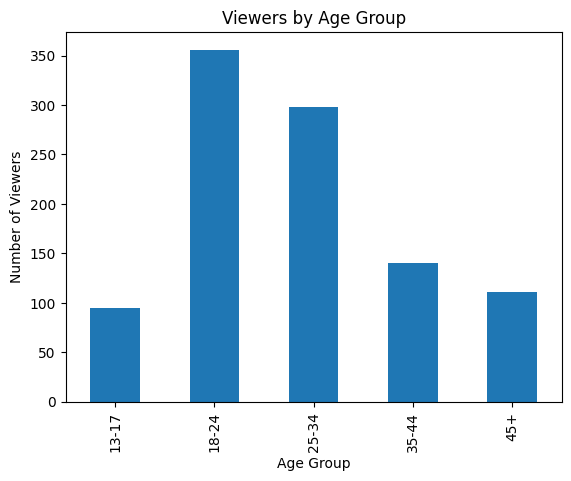

In [115]:
viewers_df['age_group'].value_counts().sort_index().plot(kind='bar')
plt.title('Viewers by Age Group')
plt.xlabel('Age Group'); plt.ylabel('Number of Viewers')
plt.show()

The viewer base skews young. The 18-24 group is the largest (356), followed by 25-34 (298). These two groups make up about 65% of all viewers. Participation drops off sharply after 34, with 35-44 (140) and 45+ (111) being much smaller, and the youngest group, 13-17 (95), is the smallest. This concentration in the 18-34 range is typical of Twitch's core demographic.

## Stream Stats

In [116]:
# Overall stream stats
streams_df[['stream_duration_hrs', 'peak_viewers']].describe()

,stream_duration_hrs,peak_viewers
count,1199.000000,1079.000000
mean,3.781485,39799.299351
std,1.597224,50747.104110
min,1.500000,57.000000
25%,2.500000,9051.000000
50%,3.000000,21421.000000
75%,5.000000,49005.000000
max,8.000000,370165.000000


Streams last 1.5 to 8 hours, averaging about 3.8 hours (median 3.0), so most fall in the 2.5 to 5 hour range. Peak viewers vary enormously, from 57 to over 370,000, with a mean of about 39,800 that sits far above the median of about 21,400. That gap signals a heavily right-skewed distribution: most streams draw modest audiences while a few massive streams pull hundreds of thousands. Note that peak_viewers has 1,079 of 1,199 values, since the rest are the missing or cleaned entries from Task 2.

In [117]:
# Session engagement merged with viewer demographics
merged = sessions_df.merge(viewers_df, on='viewer_id', how='left')
# Engagement by age group
merged.groupby('age_group')[['duration_mins', 'chat_messages_sent', 'bits_cheered']].mean()

,duration_mins,chat_messages_sent,bits_cheered
age_group,,,
13-17,58.788196,5.789624,433.931461
18-24,59.123156,6.361590,404.392848
25-34,58.884593,6.636000,392.378370
35-44,60.204120,5.859271,351.317908
45+,58.809996,7.348458,422.216235


Engagement is remarkably consistent across age groups. Average watch time sits around 59 minutes for every group, and chat messages and bits cheered show only minor variation. Age does not appear to be a strong differentiator of how viewers engage, as no group stands out as notably more or less active.

In [118]:
# Engagement by subscription tier
merged.groupby('subscription_tier')[['duration_mins', 'chat_messages_sent', 'bits_cheered']].mean()

,duration_mins,chat_messages_sent,bits_cheered
subscription_tier,,,
free,58.673101,5.258202,402.324110
free trial,60.716667,3.466667,478.066667
tier1,60.279480,6.938903,393.352333
tier2,58.487464,11.129701,374.519286
tier3,60.700781,10.491761,422.141370


A clearer pattern emerges by tier. Watch time is similar across tiers (roughly 58 to 61 minutes), but chat activity rises sharply with tier: tier2 (11.1) and tier3 (10.5) viewers send roughly double the messages of free (5.3) and tier1 (6.9) viewers. This suggests paid subscribers, especially higher tiers, are more actively engaged in chat even though they don't watch much longer. The free trial chat count of 3.5 is based on very few viewers, so it is not reliable.

## Distributions

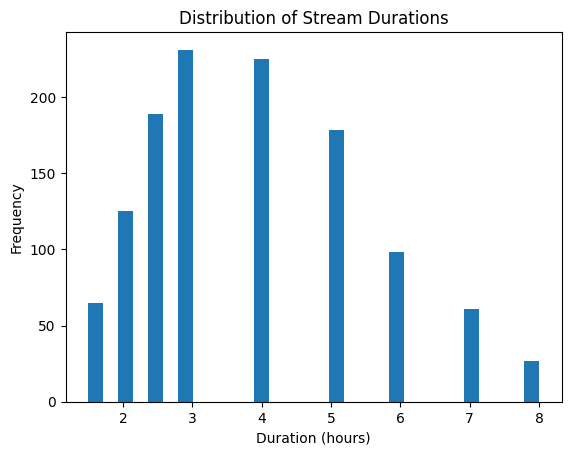

In [119]:
# Stream duration distribution
streams_df['stream_duration_hrs'].plot(kind='hist', bins=30)
plt.title('Distribution of Stream Durations')
plt.xlabel('Duration (hours)')
plt.show()

Stream durations are roughly bell-shaped but slightly right-skewed, peaking around 3 to 4 hours. Most streams fall between 2 and 5 hours, with frequency dropping off steadily past 5 hours. Very short (1.5 hour) and very long (8 hour) streams are both uncommon. This matches the summary stats: a mean of about 3.8 hours and a typical range of 2.5 to 5 hours.

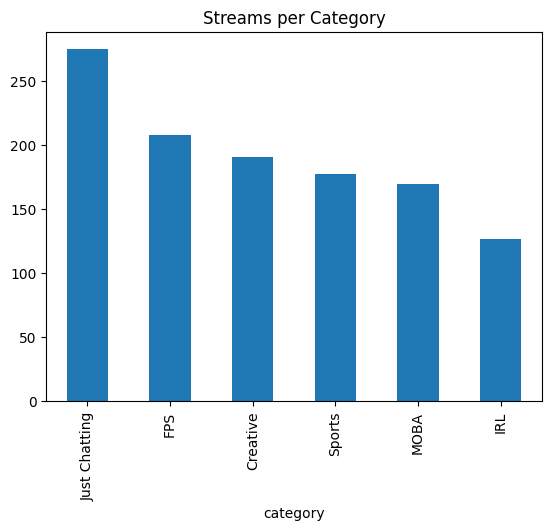

In [120]:
# Most popular categories (by number of streams)
streams_df['category'].value_counts().plot(kind='bar')
plt.title('Streams per Category')
plt.show()

Just Chatting is by far the most streamed category (275 streams), followed by FPS (208). Creative, Sports, and MOBA sit in a middle cluster around 170 to 190 streams each, while IRL is the least common (127). The spread shows a varied content mix with no category being rare, though Just Chatting clearly dominates in volume.

## Category-Specific Info

In [121]:
# Category-level: average peak viewers, stream count, total hours
streams_df.groupby('category').agg(
    stream_count=('stream_id', 'count'),
    avg_peak_viewers=('peak_viewers', 'mean'),
    avg_duration=('stream_duration_hrs', 'mean')
).sort_values('avg_peak_viewers', ascending=False)

,stream_count,avg_peak_viewers,avg_duration
category,,,
Sports,178,64527.276730,3.952247
IRL,127,47698.412281,3.866142
FPS,208,43494.904255,3.646635
Just Chatting,275,42876.719512,3.783636
MOBA,170,26709.769737,3.755882
Creative,191,13758.774566,3.657068


Stream volume does not match audience size. Sports has relatively few streams (178) but the highest average peak viewers (about 64,500), while Just Chatting has the most streams (275) yet only mid-level peaks (about 42,900). Creative is the opposite of Sports: a high stream count (191) but the lowest average peak (about 13,800). Average duration is nearly identical across categories (about 3.6 to 4.0 hours), so duration is not what separates them. The real differentiator is audience size per stream, not how long or how often streamers go live.

In [122]:
# Compare streamers — top by followers or avg concurrent viewers
streamers_df.groupby('category')[['total_followers', 'avg_concurrent_viewers']].mean()

,total_followers,avg_concurrent_viewers
category,,
Creative,1.127692e+06,7856.000000
FPS,4.346667e+06,34835.153846
IRL,3.423333e+06,32747.666667
Just Chatting,4.812143e+06,44349.277778
MOBA,2.052500e+06,17381.250000
Sports,5.581818e+06,46977.363636


Sports and Just Chatting streamers have the largest followings (about 5.6M and 4.8M average followers) and the highest average concurrent viewers, consistent with Sports also leading on peak viewers. Creative streamers have both the smallest followings (about 1.1M) and the lowest concurrent viewers (about 7,900), reinforcing that Creative is a high-volume but low-audience category. Overall, follower counts and concurrent viewers track together, and both align with the peak-viewer pattern: Sports and Just Chatting draw the biggest audiences, Creative and MOBA the smallest.

## Task 3 Summary report

Viewer base: Viewers skew young, with 18-24 (356) and 25-34 (298) making up about 65% of all viewers and participation dropping off after 34. Preferred categories are spread fairly evenly, led by Just Chatting and FPS, and account age is roughly symmetric, averaging about 5 years.

Engagement: Average watch time is consistent at around 59 minutes across all age groups and subscription tiers, so neither strongly affects how long people watch. Chat activity, however, rises clearly with subscription tier: tier2 and tier3 viewers send roughly double the messages of free and tier1 viewers, suggesting paying subscribers are more actively engaged even though they don't watch longer.

Streams: Stream durations are slightly right-skewed, peaking at 3 to 4 hours, with most between 2 and 5 hours. Just Chatting is the most streamed category (275 streams) and IRL the least (127).

Categories: Stream volume does not match audience size. Sports has relatively few streams but the highest average peak viewers (about 64,500) and largest followings, while Creative is the opposite, with high stream volume but the lowest peaks (about 13,800) and smallest followings. Since average duration is nearly identical across categories, the real differentiator is audience size per stream rather than how often or how long streamers go live.

Key insight: The most frequently streamed categories are not the ones that draw the biggest audiences, and chat engagement is driven more by subscription tier than by age.

# Task 4: Dealing with Outliers and Missing Values

- Are there any missing values or outliers in the original data? Perform the analysis and report your findings.  
- Are there any outliers or missing values in the derived data? Perform the analysis and report your findings.  
- If there are no outliers or missing values, introduce 3–5% of missing values in a selected column and 1–2% of outliers in another column.  
- Experiment with two strategies for imputing missing values and two strategies for handling outliers. Show how each strategy affects the characteristics of the data.


## Original Data 

Let's first take a look for missing data in the original CSV files. 

In [123]:
orig_sessions  = pd.read_csv('data/sessions.csv')
orig_streamers = pd.read_csv('data/streamers.csv')
orig_streams   = pd.read_csv('data/streams.csv')
orig_viewers   = pd.read_csv('data/viewers.csv')

print(orig_streamers.isnull().sum())
print(orig_streams.isnull().sum())

# Outliers / impossible values in the originals (before cleaning)
print("\nNegative followers:", (orig_streamers['total_followers'] < 0).sum())
print("Negative peak_viewers:", (orig_streams['peak_viewers'] < 0).sum())

streamer_id               0
streamer_name             0
category                  0
language                  8
partner_status            0
total_followers           0
avg_concurrent_viewers    0
dtype: int64
stream_id               0
streamer_id             0
started_at              0
ended_at                0
stream_duration_hrs     0
category               50
peak_viewers           80
title_has_hype_word     0
was_raid                0
dtype: int64

Negative followers: 5
Negative peak_viewers: 40


## Derived Data

In the original data, missing values appear in three columns: language (8) in streamers, and category (50) and peak_viewers (80) in streams. The other columns have no missing values. There are also impossible values that are not flagged as missing here: 5 streamers with negative total_followers and 40 streams with negative peak_viewers. These negatives are logically impossible (you cannot have negative followers or viewers) and represent errors rather than genuine data.

Now, let's look at any missing values in our cleaned data from task 2. 

In [124]:
# Same checks on the cleaned versions
print(streamers_df.isnull().sum())
print(streams_df.isnull().sum())

print("\nNegative followers:", (streamers_df['total_followers'] < 0).sum())   # now 0
print("Negative peak_viewers:", (streams_df['peak_viewers'] < 0).sum())     # now 0

streamer_id               0
streamer_name             0
category                  0
language                  8
partner_status            0
total_followers           5
avg_concurrent_viewers    0
dtype: int64
stream_id                0
streamer_id              0
started_at               0
ended_at                 0
stream_duration_hrs      0
category                50
peak_viewers           120
title_has_hype_word      0
was_raid                 0
dtype: int64

Negative followers: 0
Negative peak_viewers: 0


In the cleaned data, the impossible negative values are gone (0 negative followers, 0 negative peak_viewers). In their place, the missing-value counts rose: total_followers went from 0 to 5, and peak_viewers from 80 to 120 (the original 80 plus the 40 converted negatives). The 8 missing language and 50 missing category values carry over unchanged. This shows that cleaning did not erase the problem data so much as reclassify it: impossible values were converted into honest missing values, which can now be handled with a principled imputation strategy rather than left as misleading negatives.

## Imputation 

To demonstrate the difference of strategies for imputation, lets play with mean imputation vs median imputation on the missing values for peak viewers in streams.csv

In [125]:
peak_mean = streams_df.copy()
peak_median = streams_df.copy()

# Strategy 1: mean imputation
mean_val = streams_df['peak_viewers'].mean()
peak_mean['peak_viewers'] = peak_mean['peak_viewers'].fillna(mean_val)

# Strategy 2: median imputation
median_val = streams_df['peak_viewers'].median()
peak_median['peak_viewers'] = peak_median['peak_viewers'].fillna(median_val)

print(f"Mean used:   {mean_val:.0f}")
print(f"Median used: {median_val:.0f}\n")

for name, d in [('Original (NaNs dropped)', streams_df), 
                ('Mean imputed', peak_mean), 
                ('Median imputed', peak_median)]:
    col = d['peak_viewers']
    print(f"{name}:")
    print(f"  mean={col.mean():.0f}, median={col.median():.0f}, "
          f"std={col.std():.0f}, count={col.count()}\n")

Mean used:   39799
Median used: 21421

Original (NaNs dropped):
  mean=39799, median=21421, std=50747, count=1079

Mean imputed:
  mean=39799, median=26504, std=48138, count=1199

Median imputed:
  mean=37960, median=21421, std=48454, count=1199



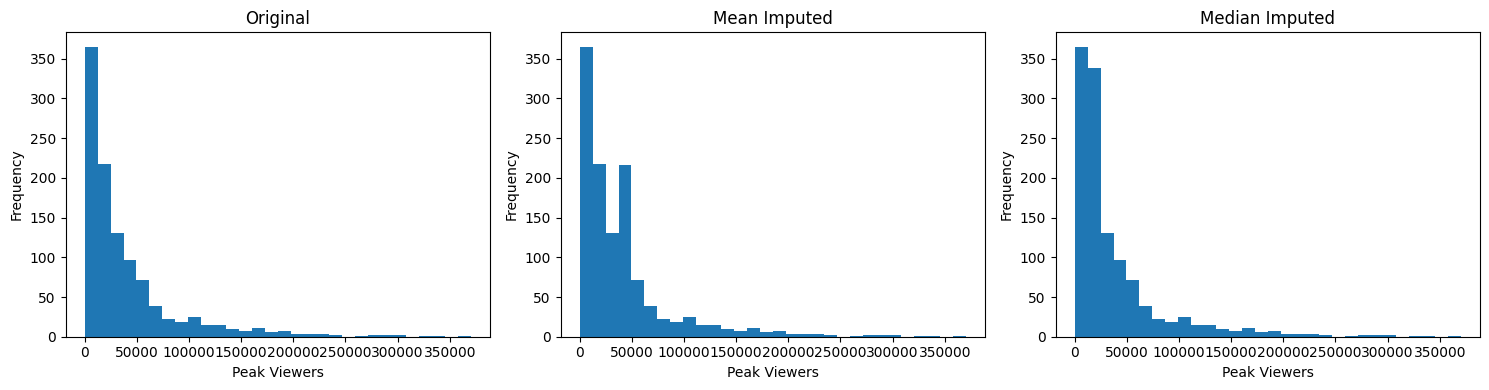

In [126]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
streams_df['peak_viewers'].plot(kind='hist', bins=30, ax=axes[0], title='Original')
peak_mean['peak_viewers'].plot(kind='hist', bins=30, ax=axes[1], title='Mean Imputed')
peak_median['peak_viewers'].plot(kind='hist', bins=30, ax=axes[2], title='Median Imputed')
for ax in axes:
    ax.set_xlabel('Peak Viewers')
plt.tight_layout()
plt.show()

Both strategies fill the 120 missing peak_viewers values, but they affect the distribution differently. Mean imputation inserts the value 39,799 into all 120 rows, which sits in the sparse middle of this right-skewed distribution. This is visible as an artificial spike around 40,000 in the Mean Imputed histogram, a bump where the real data has very few streams. It also pulls the median up from 21,421 to 26,504, distorting the center of the data.

Median imputation inserts 21,421, which sits within the dense low end where most streams already fall. The Median Imputed histogram stays much closer to the original shape, with no artificial gap or out-of-place spike. It keeps the median unchanged and lowers the mean only slightly (39,799 to 37,960).

For this heavily right-skewed column, median imputation is the better choice. It places the filled values where real data already concentrates rather than in a low-density region, so it preserves the distribution's shape far better than mean imputation.

## Outliers

We're going to also play with two strategies for outliers. Again, we'll use peak_viewers from streams. 

Let's first identify the outliers. 

In [127]:
q1, q3 = streams_df['peak_viewers'].quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 1.5 * iqr
print(f"Upper bound for outliers: {upper:.0f}")
print(f"Outliers above bound: {(streams_df['peak_viewers'] > upper).sum()}")

Upper bound for outliers: 108936
Outliers above bound: 98


The two strategies we'll try are removing outliers vs clipping outliers to upper bounds. 

In [128]:
# Strategy 1: remove outlier rows
removed = streams_df[streams_df['peak_viewers'] <= upper]

# Strategy 2: cap (clip) outliers to the upper bound
capped = streams_df.copy()
capped['peak_viewers'] = capped['peak_viewers'].clip(upper=upper)

# Compare
for name, d in [('Original', streams_df), ('Removed', removed), ('Capped', capped)]:
    col = d['peak_viewers']
    print(f"{name}: n={len(d)}, mean={col.mean():.0f}, "
          f"max={col.max():.0f}, std={col.std():.0f}")

Original: n=1199, mean=39799, max=370165, std=50747
Removed: n=981, mean=26707, max=108911, std=24887
Capped: n=1199, mean=34176, max=108936, std=33495


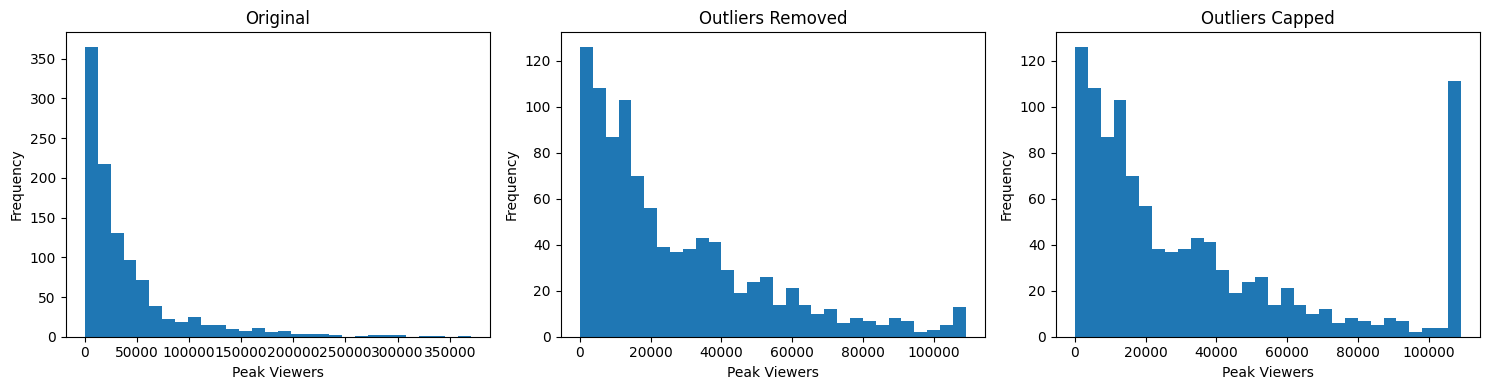

In [129]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
streams_df['peak_viewers'].plot(kind='hist', bins=30, ax=axes[0], title='Original')
removed['peak_viewers'].plot(kind='hist', bins=30, ax=axes[1], title='Outliers Removed')
capped['peak_viewers'].plot(kind='hist', bins=30, ax=axes[2], title='Outliers Capped')
for ax in axes:
    ax.set_xlabel('Peak Viewers')
plt.tight_layout()
plt.show()

The IQR method flagged 98 streams with peak_viewers above the upper bound of 108,936. The two strategies handle them differently.

Removing outliers drops these rows entirely. This lowers the mean from 39,799 to 26,707 and roughly halves the standard deviation (50,747 to 24,887), giving a tighter distribution. Note that the naive filter also dropped the 120 missing values (NaN is not <= the bound), so the row count fell by 218 rather than 98 - removal conflated outlier handling with missing-value removal.

Capping keeps all rows but clips the 98 outliers down to the bound. This also reduces the mean (to 34,176) and std (to 33,495), but less aggressively than removal since the extreme values are retained at the cap rather than deleted. The capped histogram shows a distinct spike at the right edge (around 108,936) where all 98 capped values now pile up.

Capping is the better choice here. It preserves the full dataset and the fact that these were high-viewership streams (they remain the largest values, just bounded), whereas removal discards 98 legitimate high-traffic streams and loses information about the top of the distribution. The trade-off is the artificial spike at the cap, which should be noted.

## Task 4 Summary report

I compared missing values and outliers between the original data and the cleaned (derived) data, then tested strategies for handling each.

Original vs cleaned: The original data had missing values in language (8), category (50), and peak_viewers (80), plus impossible negatives in total_followers (5) and peak_viewers (40). After cleaning, the negatives were gone but the missing counts rose accordingly (total_followers 0 to 5, peak_viewers 80 to 120). Cleaning did not remove the bad data so much as reclassify impossible values as honest missing values, which then need imputation. The dataset already contained substantial missing values and outliers, so no artificial injection was needed.

Imputation (peak_viewers, 120 missing): I compared mean (39,799) and median (21,421) imputation. Because peak_viewers is heavily right-skewed, mean imputation created an artificial spike around 40,000 in a low-density region and pulled the median up from 21,421 to 26,504. Median imputation placed the filled values where real data already concentrates, preserving the distribution's shape and leaving the median unchanged. Median is the better choice for this skewed column.

Outliers (peak_viewers): The IQR method flagged 98 streams above 108,936. Removing them tightened the distribution (mean 39,799 to 26,707, std halved) but discarded legitimate high-traffic streams, and the naive filter also dropped the 120 NaNs, conflating two operations. Capping clipped the 98 values to the bound, preserving all rows and the fact that these were high-viewership streams, at the cost of a small spike at the cap. Since these extreme values are plausible (Sports streams genuinely draw large audiences) rather than errors, capping is preferred over removal.

Overall: For this skewed, multi-table dataset, median imputation and capping both work by keeping the data's real structure intact rather than distorting or discarding it. This continues the Task 2 theme that the right fix depends on whether a value is a genuine error or a legitimate extreme.

# Task 5: Correlation and Behavioral Patterns

- Compute pairwise correlations between user features and the number of check-ins  
- Visualize the results using a correlation matrix (use a coolwarm color scheme and proper scaling)  
- Try Spearman rank correlation and explain when it is more appropriate than Pearson

In [130]:
per_viewer = sessions_df.groupby('viewer_id').agg(
    session_count=('session_id', 'count'),        # the "check-ins" equivalent
    avg_duration=('duration_mins', 'mean'),
    total_chat=('chat_messages_sent', 'sum'),
    total_bits=('bits_cheered', 'sum')
).reset_index()

viewer_features = per_viewer.merge(
    viewers_df[['viewer_id', 'account_age_days']], on='viewer_id', how='left'
)

print(viewer_features.head())

  viewer_id  session_count  avg_duration  total_chat  total_bits  \
0  VWR00001              1    281.000000          14           0   
1  VWR00002              3     30.000000           3           0   
2  VWR00003              3    108.333333          56           0   
3  VWR00004              2     45.000000           6           0   
4  VWR00005              2     34.500000           3           0   

   account_age_days  
0               355  
1              1670  
2              1108  
3               822  
4              2226  


In [131]:
tier_order = {'free': 0, 'free trial': 1, 'tier1': 2, 'tier2': 3, 'tier3': 4}
age_order = {'13-17': 0, '18-24': 1, '25-34': 2, '35-44': 3, '45+': 4}

vf = viewer_features.merge(
    viewers_df[['viewer_id', 'subscription_tier', 'age_group']], on='viewer_id', how='left'
)
vf['tier_code'] = vf['subscription_tier'].map(tier_order)
vf['age_code'] = vf['age_group'].map(age_order)

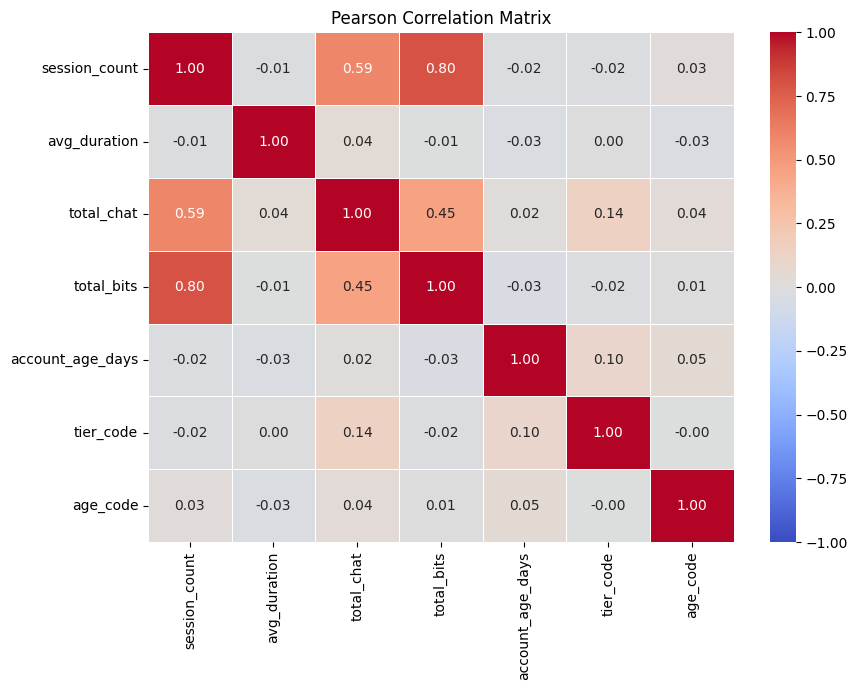

In [132]:
numeric_cols = ['session_count', 'avg_duration', 'total_chat',
                'total_bits', 'account_age_days', 'tier_code', 'age_code']
corr = vf[numeric_cols].corr()   # Pearson by default

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f',
            vmin=-1, vmax=1, center=0, linewidths=0.5)
plt.title('Pearson Correlation Matrix')
plt.tight_layout()
plt.show()

The Pearson matrix shows a few clear relationships. The strongest is between session_count and total_bits (0.80): viewers who watch more often also cheer more bits overall. session_count and total_chat are also moderately related (0.59), and total_chat and total_bits correlate at 0.45 — all consistent with the idea that more active viewers do more of everything (watch, chat, and cheer).

Outside the behavioural counts, correlations are weak. account_age_days, tier_code, and age_code show almost no linear relationship with engagement (all near 0), with the largest being a mild 0.14 between tier_code and total_chat. avg_duration is essentially uncorrelated with everything, matching the Task 3 finding that watch time per session is fairly constant across viewers. Overall, how engaged a viewer is relates to other engagement measures, but not to their demographics or account age.

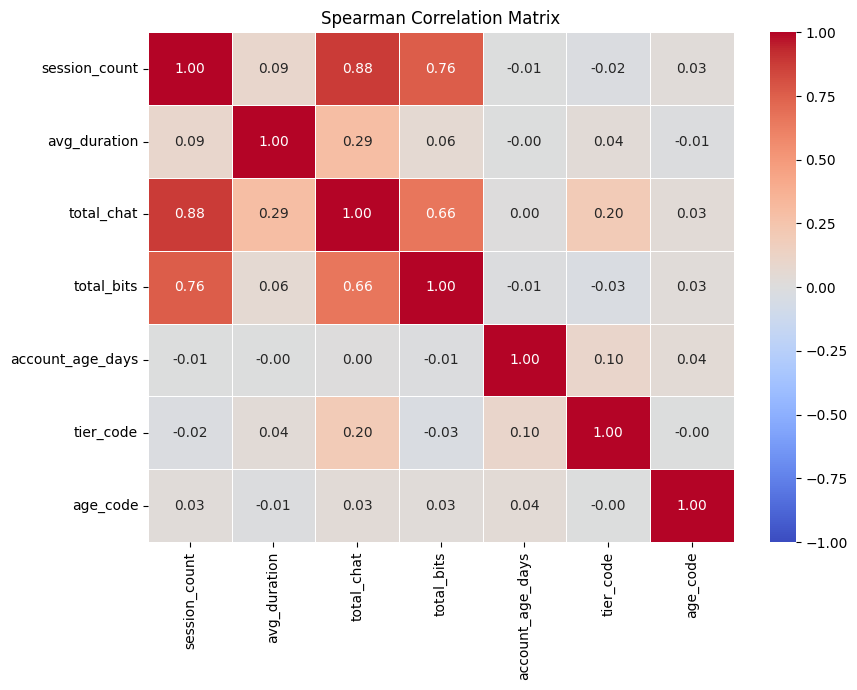

In [133]:
corr_spearman = vf[numeric_cols].corr(method='spearman')

plt.figure(figsize=(9, 7))
sns.heatmap(corr_spearman, annot=True, cmap='coolwarm', fmt='.2f',
            vmin=-1, vmax=1, center=0, linewidths=0.5)
plt.title('Spearman Correlation Matrix')
plt.tight_layout()
plt.show()

Pearson correlation measures the strength of a *linear* relationship between two variables and uses the actual values, which makes it sensitive to outliers and to skewed distributions. Spearman correlation instead ranks the values and measures whether the relationship is *monotonic* (consistently increasing or decreasing), regardless of whether it is linear.

Spearman is more appropriate when:
- The data is skewed or contains outliers, since ranking reduces the influence of extreme values. Several of these columns (total_bits, total_chat) are heavily right-skewed, so Spearman gives a more robust picture.
- The relationship may be monotonic but not linear (e.g., engagement rising with tier but not at a constant rate).
- A variable is ordinal (like tier_code or age_code), where the spacing between categories is not necessarily equal, so ranks are more meaningful than raw values.

Given the strong skew in the behavioural counts and the ordinal encoding of tier and age, the Spearman matrix is likely the more trustworthy of the two here.

The Spearman matrix tells a similar story but with notable shifts in the behavioural counts, because it ranks values and is less affected by the heavy right-skew in these columns. The session_count and total_chat correlation rises from 0.59 (Pearson) to 0.88 (Spearman), and avg_duration and total_chat goes from 0.04 to 0.29. These increases indicate the relationships are strongly monotonic but not strictly linear — Pearson understated them because a few extreme values distorted the linear fit. Conversely, session_count and total_bits drops slightly (0.80 to 0.76), and tier_code and total_chat rises from 0.14 to 0.20, reinforcing the modest "higher tiers chat more" pattern.

The demographic variables (account_age_days, age_code) remain near zero under both methods, so that null result is robust regardless of correlation type.

The most informative difference is session_count vs total_chat: 0.59 under Pearson but 0.88 under Spearman. This large gap is exactly the case where Spearman is more appropriate — the relationship is clearly monotonic (more sessions consistently means more chat) but the raw values are so skewed that the linear Pearson measure understates the true strength of the association. Because most of these behavioural columns are heavily right-skewed, the Spearman results are the more trustworthy reflection of the underlying relationships here.

## Task 5 Summary report

I aggregated session activity to one row per viewer (session_count as the engagement count, plus average duration, total chat, and total bits), joined viewer attributes (account age, and ordinally-encoded tier and age group), and computed pairwise correlations using both Pearson and Spearman.

Findings: The clearest relationships are among the behavioural counts. Viewers who watch more often also cheer more (session_count and total_bits, 0.80 Pearson) and chat more (session_count and total_chat, 0.59 Pearson rising to 0.88 Spearman). This pattern reflects that more active viewers simply do more of everything. Demographic and account features showed almost no correlation with engagement: account_age_days and age_code stayed near zero under both methods, and tier_code correlated only weakly with chat (0.14 to 0.20), a faint echo of the Task 3 finding that higher tiers chat more. avg_duration was largely uncorrelated with everything, consistent with watch time per session being fairly constant across viewers.

Pearson vs Spearman: Several behavioural correlations were noticeably stronger under Spearman, most strikingly session_count and total_chat (0.59 to 0.88). Because Spearman ranks values rather than using raw amounts, it is more appropriate when data is skewed, contains outliers, or has monotonic-but-nonlinear relationships, and when variables are ordinal (like tier and age). The large Pearson-to-Spearman gap signals that these relationships are strongly monotonic but not strictly linear, with the right-skew causing Pearson to understate them. Given the heavy skew in the count columns, the Spearman results are the more trustworthy here.

# Task 6: Compare Behavior Across User Segments

- Segment users into 2–3 groups (e.g., by age bracket, account tire)  
- Compare their viewing behavior over time using boxplots or dot plots  
- Identify any outliers in group behavior and investigate them

Let's segment by account tier

In [134]:
vf = sessions_df.groupby('viewer_id').agg(
    session_count=('session_id', 'count'),
    avg_duration=('duration_mins', 'mean'),
    total_chat=('chat_messages_sent', 'sum'),
    total_bits=('bits_cheered', 'sum')
).reset_index().merge(
    viewers_df[['viewer_id', 'subscription_tier']], on='viewer_id', how='left'
)

def segment(tier):
    if pd.isna(tier):
        return None           
    if tier in ['free', 'free trial']:
        return 'Non-subscriber'
    elif tier == 'tier1':
        return 'Low tier'
    elif tier in ['tier2', 'tier3']:
        return 'High tier'
    return None

vf['segment'] = vf['subscription_tier'].apply(segment)
print(vf['segment'].value_counts(dropna=False))

segment
Non-subscriber    589
Low tier          248
High tier         149
None               14
Name: count, dtype: int64


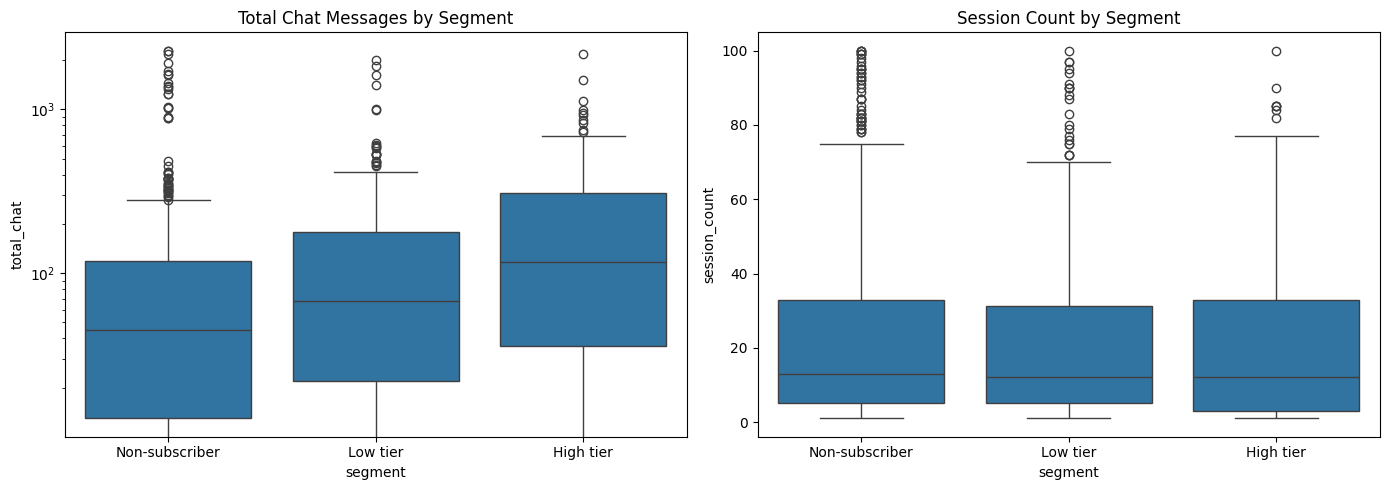

In [135]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=vf, x='segment', y='total_chat', ax=axes[0])
axes[0].set_title('Total Chat Messages by Segment')

sns.boxplot(data=vf, x='segment', y='session_count', ax=axes[1])
axes[1].set_title('Session Count by Segment')

axes[0].set_yscale('log')

plt.tight_layout()
plt.show()

The two metrics tell different stories. Total chat messages rise clearly with subscription tier: the median climbs from Non-subscriber (lowest) to Low tier to High tier, and the whole box shifts upward at each step. This confirms the pattern seen in Tasks 3 and 5 — paying viewers, especially higher tiers, are more active in chat.

Session count, by contrast, is essentially flat across all three segments. The medians sit around 12 to 13 for every group, with similar boxes and ranges. Subscribers do not watch more often than non-subscribers; they just chat more when they do. So tier is associated with chat intensity, not viewing frequency. Note the chat plot uses a log scale because of the heavy right-skew, with many high outliers visible above each box.

In [136]:
# Outliers in total_chat within each segment, via IQR per group
def group_outliers(group):
    q1, q3 = group['total_chat'].quantile([0.25, 0.75])
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    return group[group['total_chat'] > upper]

outliers = vf.groupby('segment', group_keys=False).apply(group_outliers)
print(f"Within-group chat outliers: {len(outliers)}")
print(outliers.sort_values('total_chat', ascending=False).head(10))

Within-group chat outliers: 79
    viewer_id  session_count  avg_duration  total_chat  total_bits  \
977  VWR00978            100     51.550000        2278       44802   
862  VWR00863             95     56.421053        2266       27326   
659  VWR00660             35    101.857143        2181       20200   
976  VWR00977             72     72.347222        2160       19231   
926  VWR00927             53     55.641509        1999       19678   
989  VWR00990             99     57.505051        1918       65910   
949  VWR00950             87     54.000000        1848       10127   
939  VWR00940             83     62.265060        1718       29535   
544  VWR00545              6     35.333333        1643           0   
848  VWR00849             30     51.300000        1625       12484   

    subscription_tier         segment  
977              free  Non-subscriber  
862              free  Non-subscriber  
659              free  Non-subscriber  
976             tier2       High tier 

C:\Users\User\AppData\Local\Temp\ipykernel_7160\2410836238.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  outliers = vf.groupby('segment', group_keys=False).apply(group_outliers)


In [137]:
suspect = outliers.sort_values('total_chat', ascending=False).iloc[0]['viewer_id']
print(sessions_df[sessions_df['viewer_id'] == suspect])

      session_id viewer_id streamer_id stream_id          started_at  \
44     SES000045  VWR00978     STR0049   SM00759 2024-01-05 23:16:00   
211    SES000212  VWR00978     STR0075   SM01188 2024-02-25 19:23:00   
431    SES000432  VWR00978     STR0069   SM01101 2024-02-26 12:46:00   
513    SES000514  VWR00978     STR0028   SM00441 2024-01-17 16:11:00   
539    SES000540  VWR00978     STR0046   SM00723 2024-03-05 20:17:00   
...          ...       ...         ...       ...                 ...   
20684  SES020685  VWR00978     STR0060   SM00942 2024-02-12 14:10:00   
20764  SES020765  VWR00978     STR0025   SM00397 2024-01-26 15:21:00   
21230  SES021231  VWR00978     STR0028   SM00449 2024-03-09 21:24:00   
22680  SES022681  VWR00978     STR0070   SM01109 2024-01-22 12:49:00   
22792  SES022793  VWR00978     STR0035   SM00564 2024-01-28 11:42:00   

                 ended_at  duration_mins  chat_messages_sent  bits_cheered  \
44    2024-01-06 03:12:00            236                 

Investigating the within-group chat outliers (79 viewers), the most extreme cases are dominated by Non-subscribers with very high total_chat (2,000+ messages). VWR00978 is the top example, with 100 sessions and 2,278 total messages. Inspecting its session history shows the high total is spread across many normal-length sessions (most with single or low-double-digit message counts per session), rather than one impossible burst. So this looks like a genuine super-user (a very active free viewer) rather than corrupted data or a bot.

This is consistent with the cleaning decisions from Task 2: these high-chat totals are legitimate aggregated activity from heavy users, not the sub-minute or impossible-rate sessions that were flagged earlier. The outliers are real behavioral extremes, not errors, so they should be kept rather than removed.

## Task 6 Summary report

I segmented viewers into three groups by subscription tier (Non-subscriber, Low tier, High tier) and compared their behaviour using boxplots, then investigated within-group outliers. The ~14 viewers with invalid/missing tiers were excluded.

Comparison: Total chat messages rise clearly with tier — the median and the whole distribution shift upward from Non-subscriber to Low tier to High tier, confirming the pattern from Tasks 3 and 5 that paying viewers chat more. Session count, however, is essentially flat across all three segments (medians around 12 to 13), meaning subscribers do not watch more often than non-subscribers; they just chat more when they do. So tier relates to chat intensity, not viewing frequency.

Outliers: Investigating the 79 within-group chat outliers, the most extreme were heavy chatters with 2,000+ total messages, mostly Non-subscribers. Inspecting the top case (VWR00978: 100 sessions, 2,278 messages) showed the total was spread across many normal sessions rather than one impossible burst, so these are genuine super-users rather than bots or corrupted data — real behavioural extremes that should be kept. Notably, the most extreme individual chatters were free users, showing that while subscribers chat more on average, the heaviest individual chatters are not necessarily the paying ones.

# Task 7: Your Own EDA Questions

Formulate and explore two hypotheses of your own:  
- Propose questions based on curiosity (e.g., “Does a user's variety of categories influence morning vs. evening or session duration?”)  
- Use summary statistics and visualizations to answer each question  
- Briefly discuss what additional data would help you answer the questions more effectively


## Question 1: Does time of day affect engagement?

Hypothesis: Evening sessions have higher engagement than daytime sessions.

            duration_mins  chat_messages_sent  bits_cheered
time_block                                                 
Afternoon       59.122512            6.567401    378.072278
Evening         58.926810            6.458500    392.946431
Morning         68.997901            7.863815    417.473104
Night           49.632470            4.731095    430.735325


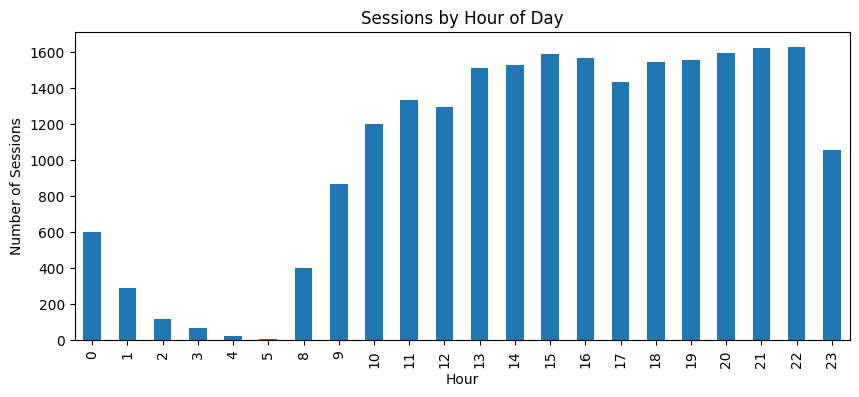

In [138]:
sessions_df['hour'] = sessions_df['started_at'].dt.hour

def time_of_day(h):
    if 5 <= h < 12:    return 'Morning'
    elif 12 <= h < 17: return 'Afternoon'
    elif 17 <= h < 22: return 'Evening'
    else:              return 'Night'

sessions_df['time_block'] = sessions_df['hour'].apply(time_of_day)

print(sessions_df.groupby('time_block')[['duration_mins', 'chat_messages_sent', 'bits_cheered']].mean())

# Session volume by hour
sessions_df['hour'].value_counts().sort_index().plot(kind='bar', figsize=(10,4),
    title='Sessions by Hour of Day')
plt.xlabel('Hour'); plt.ylabel('Number of Sessions'); plt.show()

The hour-of-day chart shows session volume follows an expected daily rhythm: very few sessions overnight (2am-5am), a steady climb through the morning, and a sustained high plateau from early afternoon through late evening (peaking around 9-10pm). So viewers clearly watch more in the afternoon and evening.

However, the engagement-per-session results contradict the hypothesis. Evening sessions do not have the highest engagement — in fact Morning sessions have the highest average duration (69 min vs ~59 for afternoon/evening) and the most chat messages (7.9), while Night sessions have the lowest duration (50 min) and chat (4.7). Bits cheered actually rise slightly at night (431). So while the evening has the most sessions, it does not have the most engaged sessions. The hypothesis is not supported: time of day affects how many people watch far more than how intensely each person engages, and if anything mornings show the deepest per-session engagement.

Additional data that would help: viewer time zones. All timestamps are likely recorded in a single zone, so "morning" may not match each viewer's local morning. Knowing local time would let me test engagement against each viewer's actual time of day rather than a global clock.

## Question 2: Do streamers who use "hype words" in titles draw bigger audiences?

Hypothesis: Streams with a hype word in the title have higher peak viewers.

                     count          mean           std    min      25%  \
title_has_hype_word                                                      
False                769.0  40245.187256  52551.681296   57.0  8377.00   
True                 310.0  38693.209677  46027.912569  118.0  9823.25   

                         50%      75%       max  
title_has_hype_word                              
False                20255.0  50251.0  370165.0  
True                 23587.0  48075.5  272708.0  


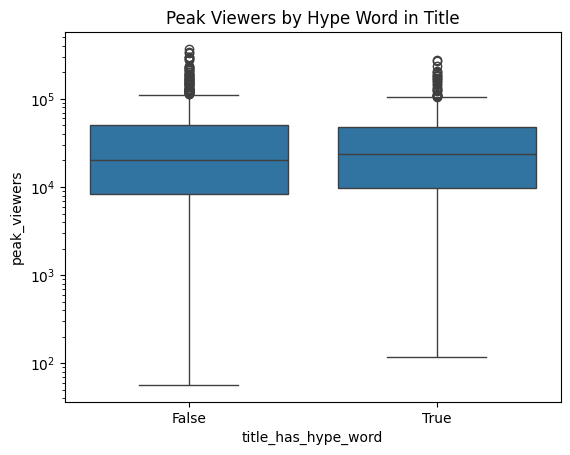

In [139]:
print(streams_df.groupby('title_has_hype_word')['peak_viewers'].describe())

import seaborn as sns
sns.boxplot(data=streams_df, x='title_has_hype_word', y='peak_viewers')
plt.yscale('log')   # peak_viewers is skewed
plt.title('Peak Viewers by Hype Word in Title')
plt.show()

The data does not support this. Streams with a hype word (310 streams) have a mean peak of 38,693 and median of 23,587, while streams without one (769 streams) have a nearly identical mean of 40,245 and median of 20,255. The boxplots are visually almost indistinguishable, with heavily overlapping boxes and similar spreads. The hype-word group has a marginally higher median but a slightly lower mean, and the difference is far too small to be meaningful given the enormous variance in peak viewers.

The hypothesis is not supported: a hype word in the title shows no practical association with audience size. Peak viewership appears to be driven by other factors (such as the streamer's existing popularity and category) rather than title wording.

Additional data that would help: the actual stream titles rather than just a boolean would let me test which specific words matter. Follower count at stream time would also let me separate any title effect from the streamer's baseline popularity, and category or scheduling data could control for confounders.

## Task 7 Summary report

I formulated and tested two hypotheses of my own.

Q1) Does time of day affect engagement? I hypothesized that evening sessions would be the most engaged. Session volume follows a clear daily rhythm (very low overnight, peaking in the afternoon and evening), but engagement per session did not match the hypothesis. Morning sessions actually had the highest average duration (69 min) and chat (7.9), while night sessions had the lowest. So time of day strongly affects how many people watch but not how intensely they engage, and the hypothesis was not supported. Viewer time zones would sharpen this, since all timestamps appear to be in a single zone and may not reflect each viewer's local time.

Q2) Do hype words in titles draw bigger audiences? I hypothesized that streams with a hype word in the title would have higher peak viewers. The data showed almost no difference: hype-word streams had a mean peak of 38,693 (median 23,587) versus 40,245 (median 20,255) without, with near-identical, heavily overlapping boxplots. The hypothesis was not supported; peak viewership seems driven by factors like streamer popularity and category rather than title wording. The actual title text and follower count at stream time would help separate any title effect from baseline popularity.

Both hypotheses were ultimately not supported, but each was a valid, evidence-based test. The honest null results are themselves informative: engagement intensity is fairly stable across the day, and title hype words do not meaningfully move audience size.

# Task 8: EDA Presentation (Insight Report)

Summarize your findings in a polished format:  
- Create 3–4 slides or a single-page report highlighting your most important insights  
- Include at least 2 charts and interpret them using clear, plain language  
- Apply Tufte’s principles: minimize chartjunk, maximize data-to-ink ratio, and ensure clear labeling  

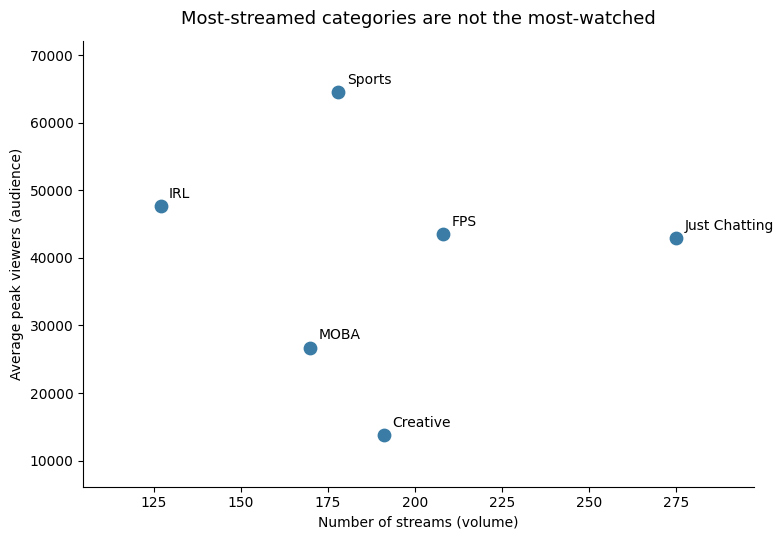

In [140]:
cat = streams_df.groupby('category').agg(
    stream_count=('stream_id', 'count'),
    avg_peak=('peak_viewers', 'mean')
).reset_index()

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(cat['stream_count'], cat['avg_peak'], s=80, color='#3a7ca5', zorder=3)

# Direct labeling (Tufte: label data, not a legend)
for _, r in cat.iterrows():
    ax.annotate(r['category'], (r['stream_count'], r['avg_peak']),
                xytext=(6, 6), textcoords='offset points', fontsize=10)

ax.set_xlabel('Number of streams (volume)')
ax.set_ylabel('Average peak viewers (audience)')
ax.set_title('Most-streamed categories are not the most-watched', fontsize=13, pad=12)

ax.spines[['top', 'right']].set_visible(False)
ax.margins(0.15)
plt.tight_layout()
plt.show()

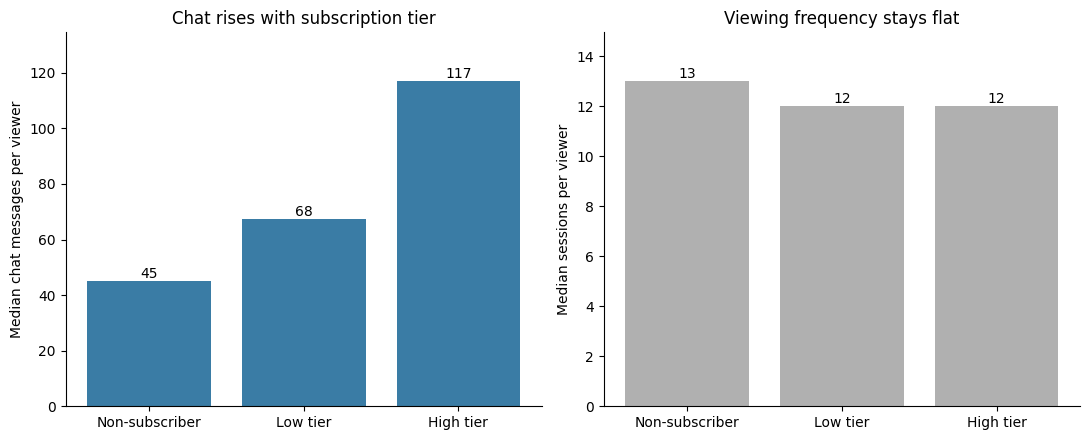

In [141]:
order = ['Non-subscriber', 'Low tier', 'High tier']
medians = vf.groupby('segment')[['total_chat', 'session_count']].median().reindex(order)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].bar(order, medians['total_chat'], color='#3a7ca5')
axes[0].set_title('Chat rises with subscription tier')
axes[0].set_ylabel('Median chat messages per viewer')

axes[1].bar(order, medians['session_count'], color='#b0b0b0')
axes[1].set_title('Viewing frequency stays flat')
axes[1].set_ylabel('Median sessions per viewer')

for ax, col in zip(axes, ['total_chat', 'session_count']):
    for i, v in enumerate(medians[col]):
        ax.text(i, v, f'{v:.0f}', ha='center', va='bottom', fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)
    ax.margins(y=0.15)

plt.tight_layout()
plt.show()